<a href="https://colab.research.google.com/github/makushin555/Six-Stock-Portfolio-Optimization-in-Python/blob/main/Portfolio%20Optimisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## COURSEWORK 4 - 6 stock portfolio analysis

### Importing python libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Reading data

In [ ]:

df_stocksall = pd.read_excel("/content/drive/MyDrive/FR2209_assessment_data.xlsx")
df_stocksall.head()

,date,A,A2A,AACA,AAK,AAL,AAP,ABBV,ABC,ABDN,...,YRI,YSHL,YUEN,YUM,ZBH,ZBRA,ZD,ZG,ZSG,ZWS
0,2013-01-31,112.27161,122.314159,1043.371845,320.626585,762.273732,548.94214,106.06728,1705.2903,178.085457,...,46.136495,105.958502,1514.832651,973.53321,253.58022,1067.1780,350.17725,105.78699,110.840781,99.899979
1,2013-02-28,103.99790,98.426092,1145.542392,353.152916,742.602644,569.99781,106.73221,1782.0613,173.685255,...,41.580070,104.225285,1525.915190,981.62867,254.80393,1102.6846,395.24708,120.10065,114.620076,101.849980
2,2013-03-29,105.52726,108.517008,1295.965253,379.467280,668.037073,617.57349,117.89110,1942.5225,180.366068,...,43.643947,104.612633,1472.578096,1078.47220,256.37671,1162.1092,434.35084,152.83761,89.729682,106.149980
3,2013-04-30,104.19465,143.660484,1315.650734,394.685795,631.702040,626.76417,134.35880,2043.3296,201.212592,...,35.101786,103.228313,1563.479895,1026.32990,260.56910,1150.2737,450.85645,164.46744,102.947839,91.099930
4,2013-05-31,114.27723,155.248864,1548.193229,402.384958,602.932562,609.12989,124.55541,2049.7012,206.679214,...,33.388506,98.317528,1321.393769,1020.75540,267.59034,1125.8626,455.70557,156.94721,93.367458,99.699936


In [ ]:
#NO NEED
selected_columns = df_stocksall.loc[:, (df_stocksall.columns == "date")]
print(selected_columns)

          date
0   2013-01-31
1   2013-02-28
2   2013-03-29
3   2013-04-30
4   2013-05-31
..         ...
115 2022-08-31
116 2022-09-30
117 2022-10-31
118 2022-11-30
119 2022-12-30

[120 rows x 1 columns]


In [ ]:
selection = np.array(["O", "LNG", "MS", "COST", "BYDE", "ASML"])


# Filter columns
df_stocksprice = df_stocksall.loc[:, df_stocksall.columns.isin(selection)]
print(df_stocksprice)

             ASML        BYDE       COST         LNG          MS          O
0     4128.097627   25.472312  1271.8238   707.66651   480.70801  1968.1602
1     3915.251962   27.527343  1262.1788   709.99952   475.40552  2065.1263
2     3697.034054   23.383646  1322.2408   933.33326   463.38868  2059.8167
3     4124.761784   40.398705  1351.1507   949.33301   468.06373  2323.4124
4     4635.486301   48.246445  1369.8702   978.33301   547.30713  2079.8382
..            ...         ...        ...         ...         ...        ...
115  29530.713683  220.385598  7881.8008  5396.74220  2201.17340  4878.9844
116  25743.210982  199.909906  7129.5469  5589.79690  2040.77320  4176.4336
117  28622.008794  240.418345  7584.5352  5943.56250  2142.39950  4486.2930
118  35479.010136  269.183896  8155.4571  5921.87500  2426.59310  4561.7969
119  32765.838055  266.011929  6903.9688  5064.12110  2216.70710  4605.8086

[120 rows x 6 columns]


In [ ]:
df_stocksret = (df_stocksprice / df_stocksprice.shift(1) - 1).dropna()
df_stocksret


,ASML,BYDE,COST,LNG,MS,O
1,-0.051560,0.080677,-0.007584,0.003297,-0.011031,0.049267
2,-0.055735,-0.150530,0.047586,0.314555,-0.025277,-0.002571
3,0.115695,0.727648,0.021864,0.017143,0.010089,0.127970
4,0.123819,0.194257,0.013854,0.030548,0.169300,-0.104835
5,-0.055869,-0.156176,0.008565,-0.054174,-0.056757,-0.073707
...,...,...,...,...,...,...
115,-0.139109,0.037324,-0.035470,0.073257,0.010913,-0.073828
116,-0.128256,-0.092908,-0.095442,0.035772,-0.072870,-0.143995
117,0.111827,0.202633,0.063817,0.063288,0.049798,0.074192
118,0.239571,0.119648,0.075274,-0.003649,0.132652,0.016830


In [ ]:
df_date = df_stocksall.loc[:, df_stocksall.columns=="date"]
print(df_date)

df_stocks = pd.concat([df_date, df_stocksret], axis=1).dropna()

#df_stocks = pd.merge(df_date, df_stocksret , on="Date", how="inner")  # 'inner', 'left', 'right', or 'outer'

print(df_stocks)

          date
0   2013-01-31
1   2013-02-28
2   2013-03-29
3   2013-04-30
4   2013-05-31
..         ...
115 2022-08-31
116 2022-09-30
117 2022-10-31
118 2022-11-30
119 2022-12-30

[120 rows x 1 columns]
          date      ASML      BYDE      COST       LNG        MS         O
1   2013-02-28 -0.051560  0.080677 -0.007584  0.003297 -0.011031  0.049267
2   2013-03-29 -0.055735 -0.150530  0.047586  0.314555 -0.025277 -0.002571
3   2013-04-30  0.115695  0.727648  0.021864  0.017143  0.010089  0.127970
4   2013-05-31  0.123819  0.194257  0.013854  0.030548  0.169300 -0.104835
5   2013-06-28 -0.055869 -0.156176  0.008565 -0.054174 -0.056757 -0.073707
..         ...       ...       ...       ...       ...       ...       ...
115 2022-08-31 -0.139109  0.037324 -0.035470  0.073257  0.010913 -0.073828
116 2022-09-30 -0.128256 -0.092908 -0.095442  0.035772 -0.072870 -0.143995
117 2022-10-31  0.111827  0.202633  0.063817  0.063288  0.049798  0.074192
118 2022-11-30  0.239571  0.119648  0.075274 -

### Check for date format

In [ ]:
type(df_stocks.loc[1,'date'])

pandas._libs.tslibs.timestamps.Timestamp

### Building line plots

#### O Return

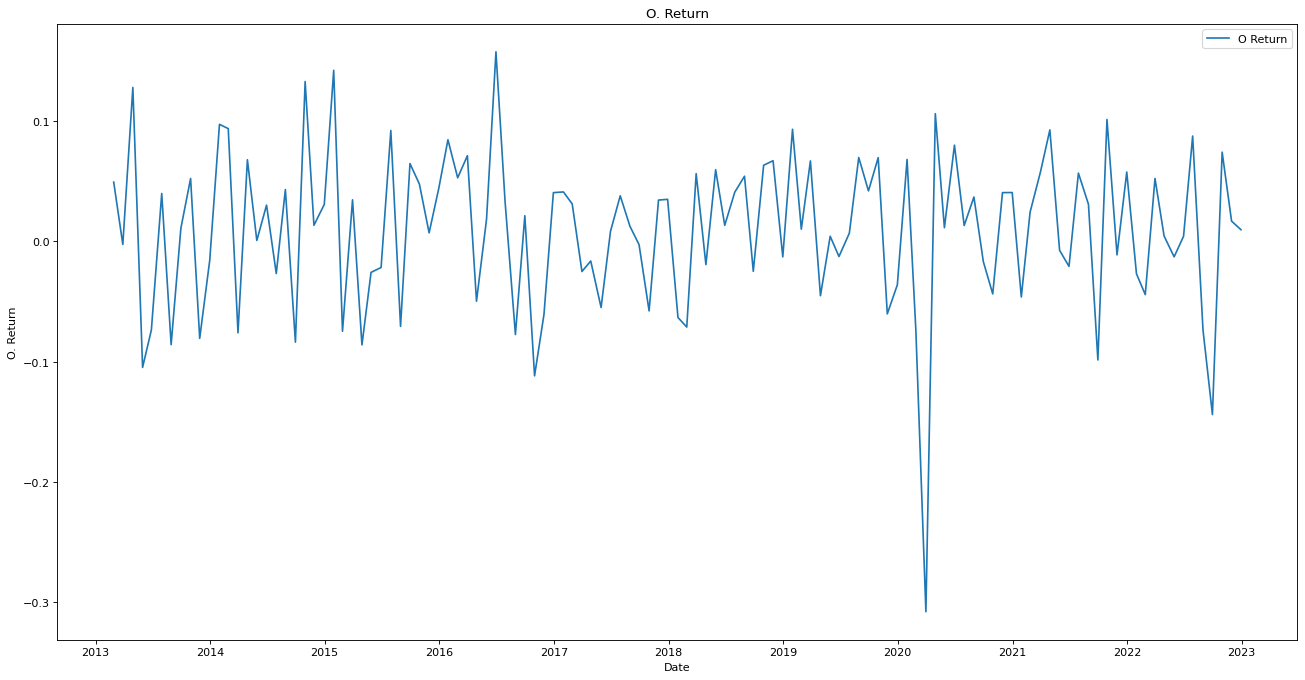

In [ ]:
# plt.figure(figsize=(20, 10), dpi=80)
# plt.plot(df_stocks['date'], df_stocks['O'], label = "O Return")
# plt.legend()
# plt.xlabel('Date')
# plt.ylabel('O. Return')
# plt.title('O. Return')
# plt.savefig("O._returns.pdf")

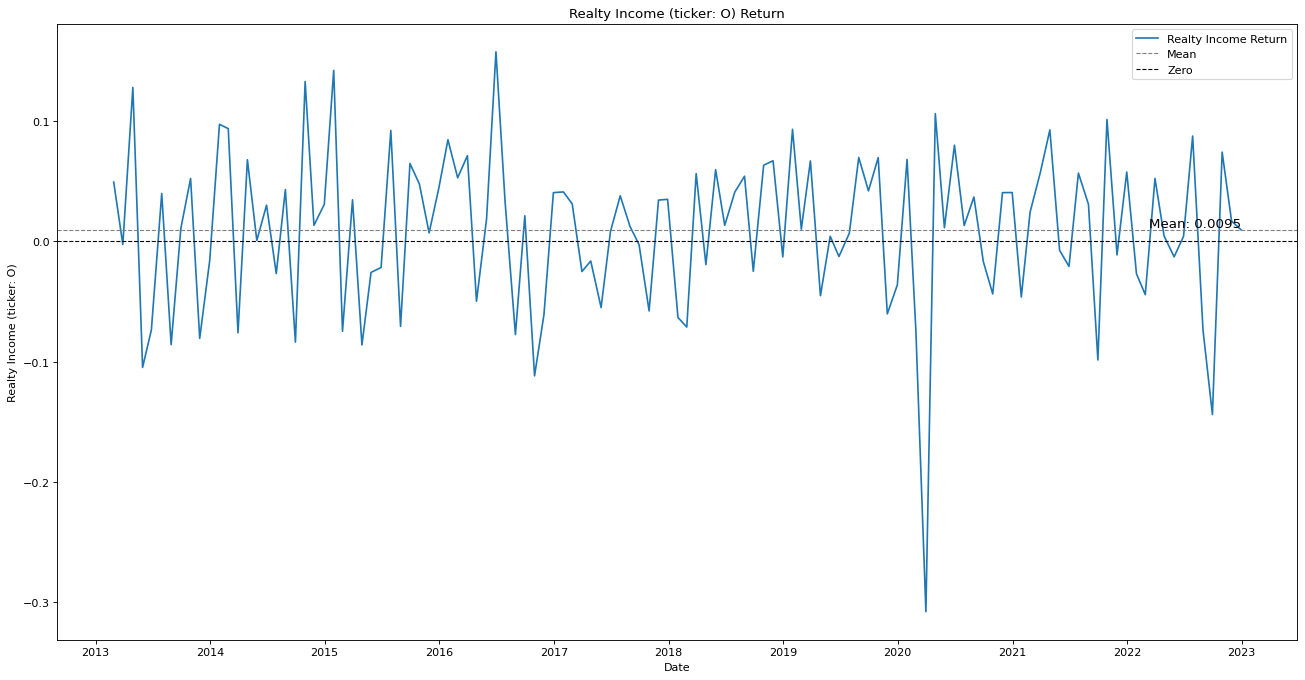

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10), dpi=80)
plt.plot(df_stocks['date'], df_stocks['O'], label="Realty Income Return")

# Draw horizontal lines
plt.axhline(y=mu["O"], color='grey', linestyle='--', linewidth=1, label='Mean')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1, label='Zero')

# Annotate the mean line
plt.text(df_stocks['date'].iloc[-1], mu["O"], f'Mean: {mu["O"]:.4f}',
         va='bottom', ha='right', fontsize=12, color='black')

plt.legend()
plt.xlabel('Date')
plt.ylabel('Realty Income (ticker: O)')
plt.title('Realty Income (ticker: O) Return')
plt.savefig("O._returns.pdf")


#### MS Return

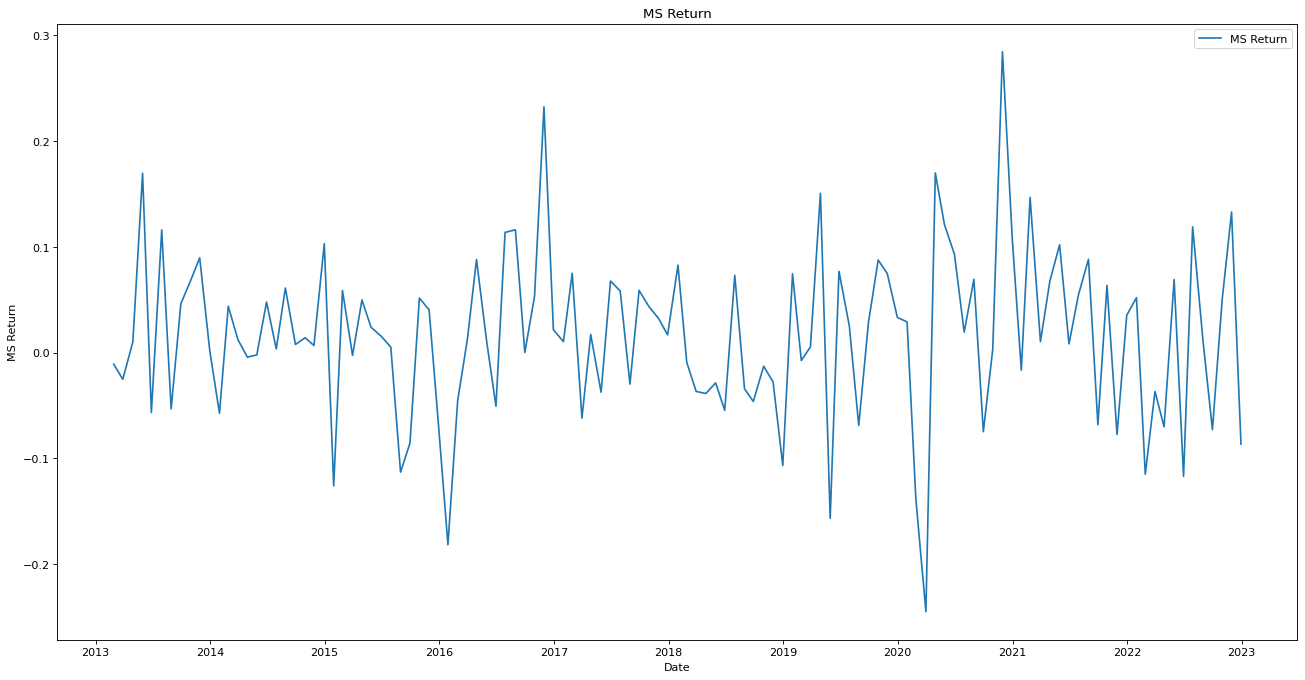

In [ ]:
# plt.figure(figsize=(20, 10), dpi=80)
# plt.plot(df_stocks['date'], df_stocks['MS'], label = "MS Return")
# plt.legend()
# plt.xlabel('Date')
# plt.ylabel('MS Return')
# plt.title('MS Return')
# plt.savefig("MS_returns.pdf")

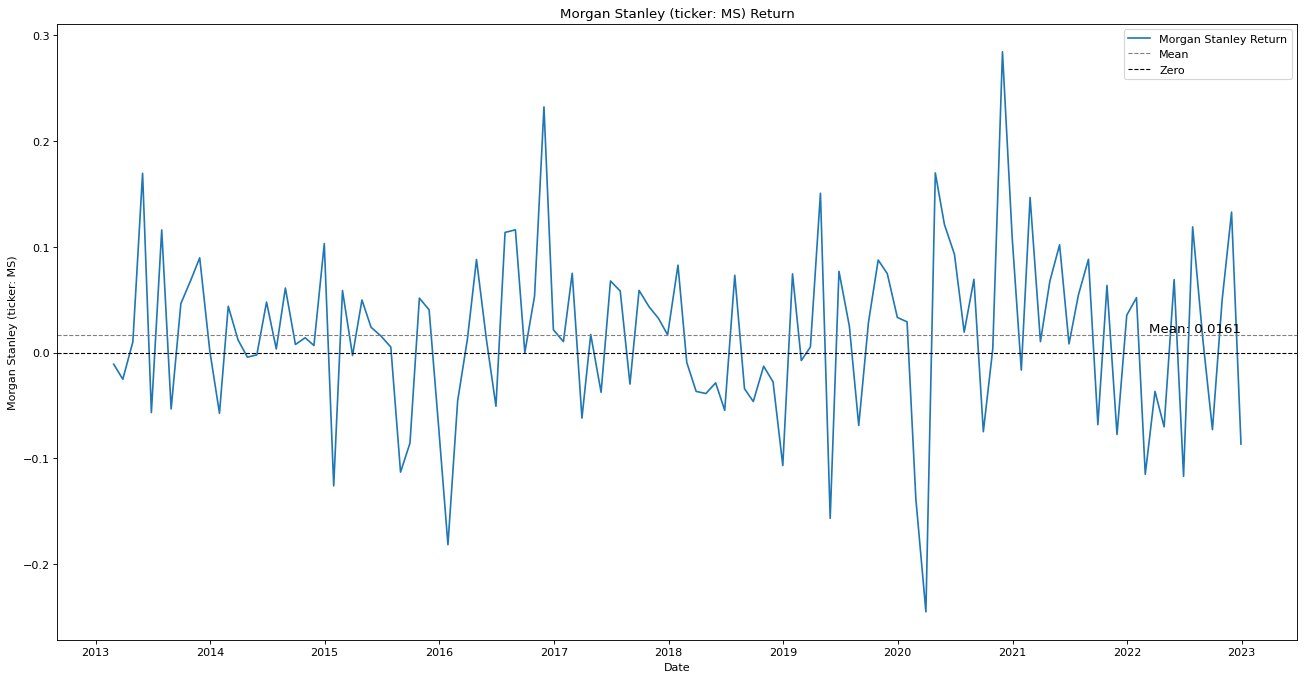

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10), dpi=80)
plt.plot(df_stocks['date'], df_stocks['MS'], label="Morgan Stanley Return")

# Draw horizontal lines
plt.axhline(y=mu["MS"], color='grey', linestyle='--', linewidth=1, label='Mean')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1, label='Zero')

# Annotate the mean line
plt.text(df_stocks['date'].iloc[-1], mu["MS"], f'Mean: {mu["MS"]:.4f}',
         va='bottom', ha='right', fontsize=12, color='black')

plt.legend()
plt.xlabel('Date')
plt.ylabel('Morgan Stanley (ticker: MS)')
plt.title('Morgan Stanley (ticker: MS) Return')
plt.savefig("ms.pdf")


#### ASML Return

In [ ]:
# plt.figure(figsize=(20, 10), dpi=80)
# plt.plot(df_stocks['date'], df_stocks['ASML'], label = "ASML Return")
# plt.legend()
# plt.xlabel('Date')
# plt.ylabel('ASML Return')
# plt.title('ASML Return')
# plt.savefig("ASML_returns.pdf")

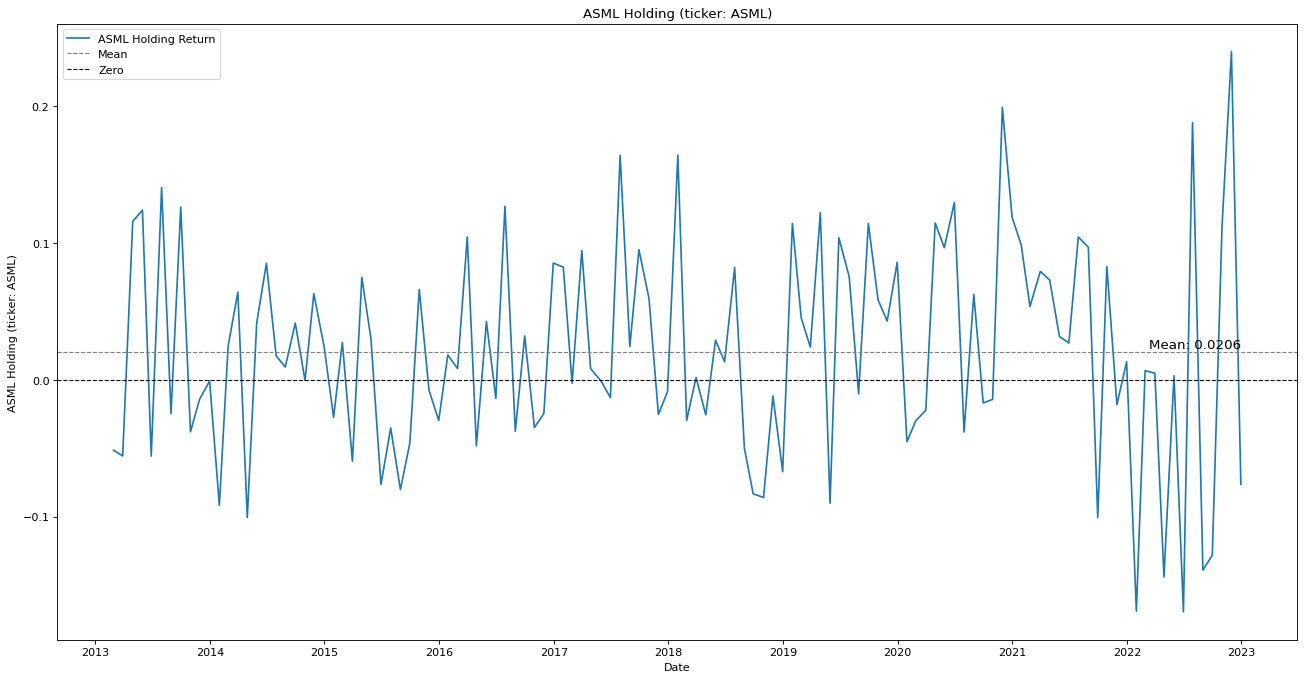

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10), dpi=80)
plt.plot(df_stocks['date'], df_stocks['ASML'], label="ASML Holding Return")

# Draw horizontal lines
plt.axhline(y=mu["ASML"], color='grey', linestyle='--', linewidth=1, label='Mean')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1, label='Zero')

# Annotate the mean line
plt.text(df_stocks['date'].iloc[-1], mu["ASML"], f'Mean: {mu["ASML"]:.4f}',
         va='bottom', ha='right', fontsize=12, color='black')

plt.legend()
plt.xlabel('Date')
plt.ylabel('ASML Holding (ticker: ASML)')
plt.title('ASML Holding (ticker: ASML)')
plt.savefig("ASML.pdf")

#### BYD Return

In [ ]:
# plt.figure(figsize=(20, 10), dpi=80)
# plt.plot(df_stocks['date'], df_stocks['BYDE'], label = "BYD Return")
# plt.legend()
# plt.xlabel('Date')
# plt.ylabel('BYD Return')
# plt.title('BYD Return')
# plt.savefig("BYD_returns.pdf")


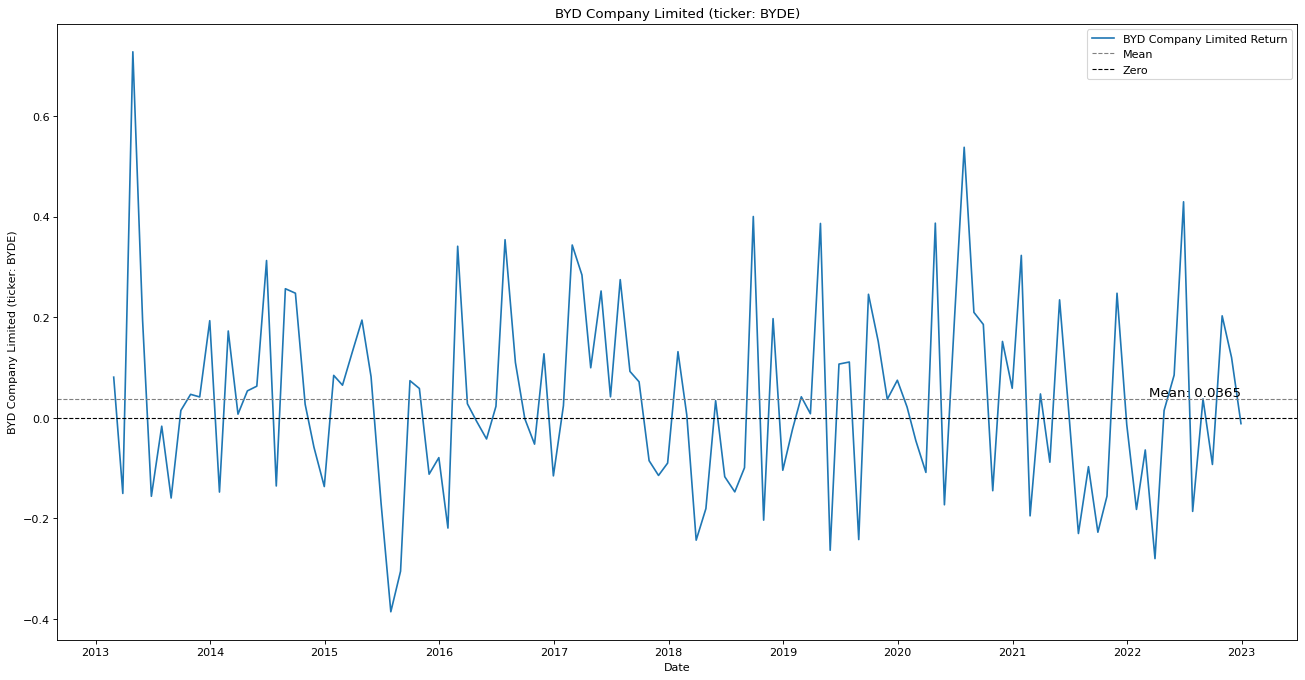

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10), dpi=80)
plt.plot(df_stocks['date'], df_stocks['BYDE'], label="BYD Company Limited Return")

# Draw horizontal lines
plt.axhline(y=mu["BYDE"], color='grey', linestyle='--', linewidth=1, label='Mean')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1, label='Zero')

# Annotate the mean line
plt.text(df_stocks['date'].iloc[-1], mu["BYDE"], f'Mean: {mu["BYDE"]:.4f}',
         va='bottom', ha='right', fontsize=12, color='black')

plt.legend()
plt.xlabel('Date')
plt.ylabel('BYD Company Limited (ticker: BYDE)')
plt.title('BYD Company Limited (ticker: BYDE)')
plt.savefig("BYDE.pdf")

#### CostCO Return

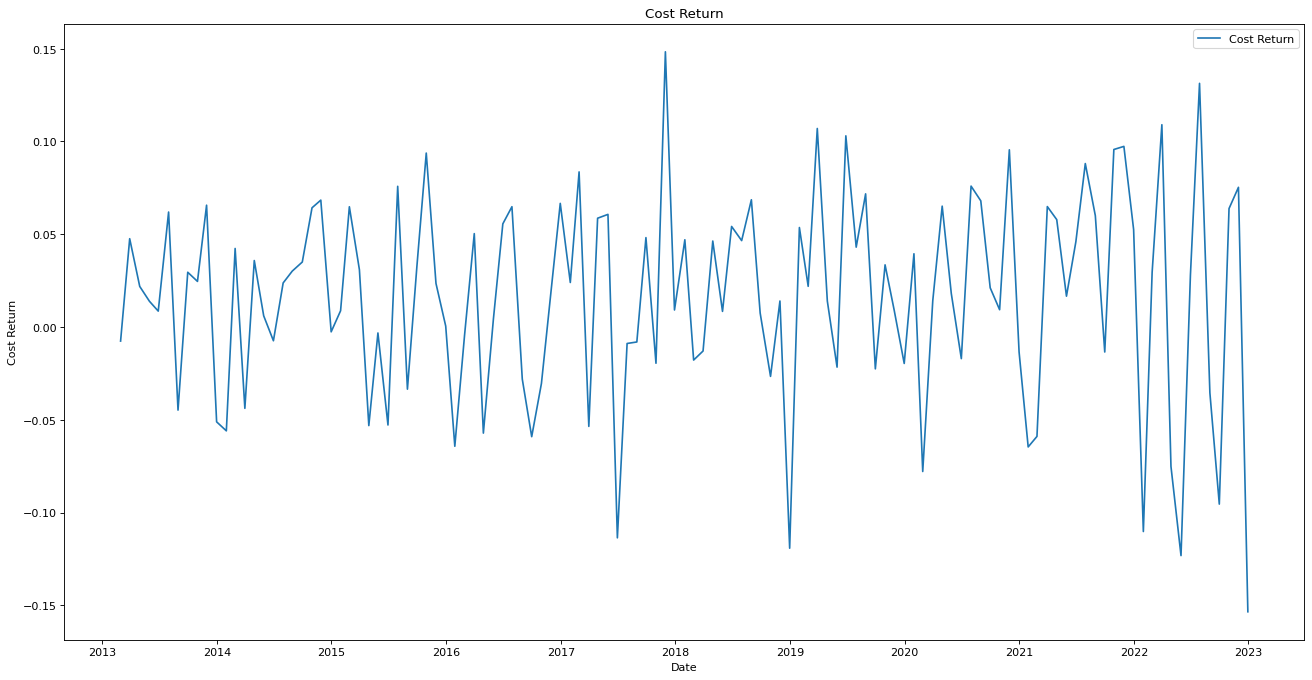

In [ ]:
# plt.figure(figsize=(20, 10), dpi=80)
# plt.plot(df_stocks['date'], df_stocks['COST'], label = "Cost Return")
# plt.legend()
# plt.xlabel('Date')
# plt.ylabel('Cost Return')
# plt.title('Cost Return')
# plt.savefig("Cost_returns.pdf")

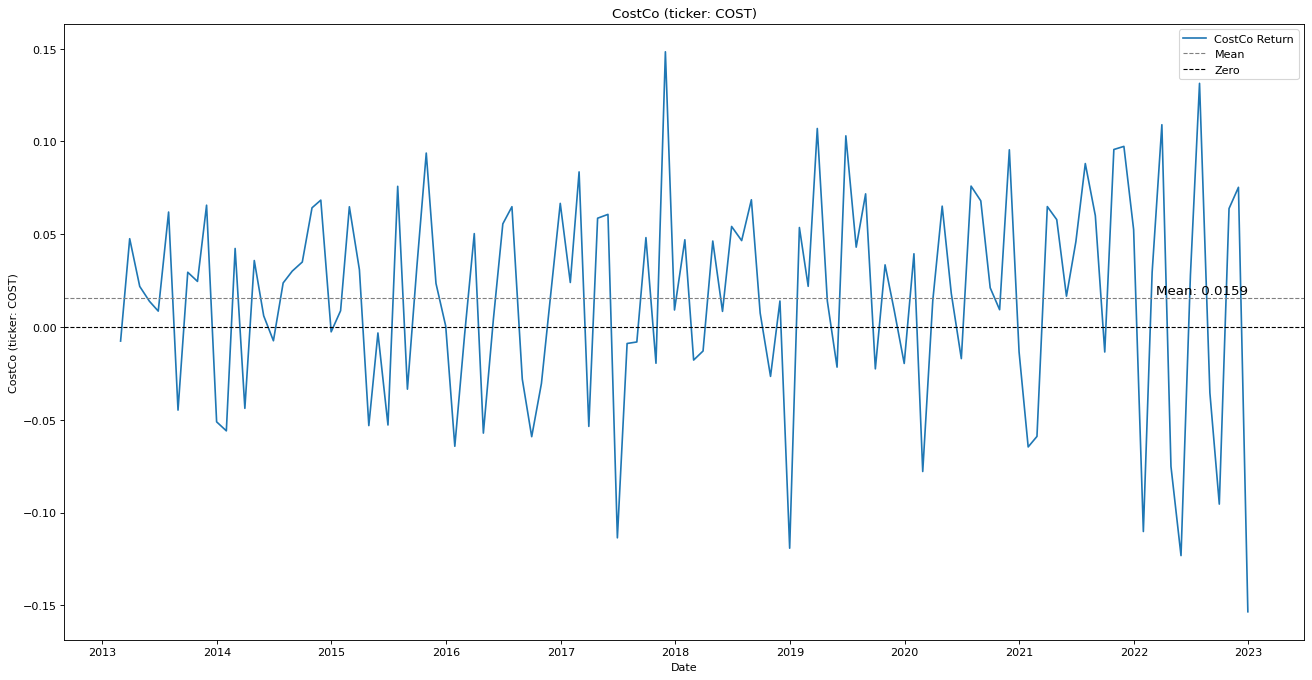

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10), dpi=80)
plt.plot(df_stocks['date'], df_stocks['COST'], label="CostCo Return")

# Draw horizontal lines
plt.axhline(y=mu["COST"], color='grey', linestyle='--', linewidth=1, label='Mean')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1, label='Zero')

# Annotate the mean line
plt.text(df_stocks['date'].iloc[-1], mu["COST"], f'Mean: {mu["COST"]:.4f}',
         va='bottom', ha='right', fontsize=12, color='black')

plt.legend()
plt.xlabel('Date')
plt.ylabel('CostCo (ticker: COST)')
plt.title('CostCo (ticker: COST)')
plt.savefig("Cost.pdf")

#### LNG Return

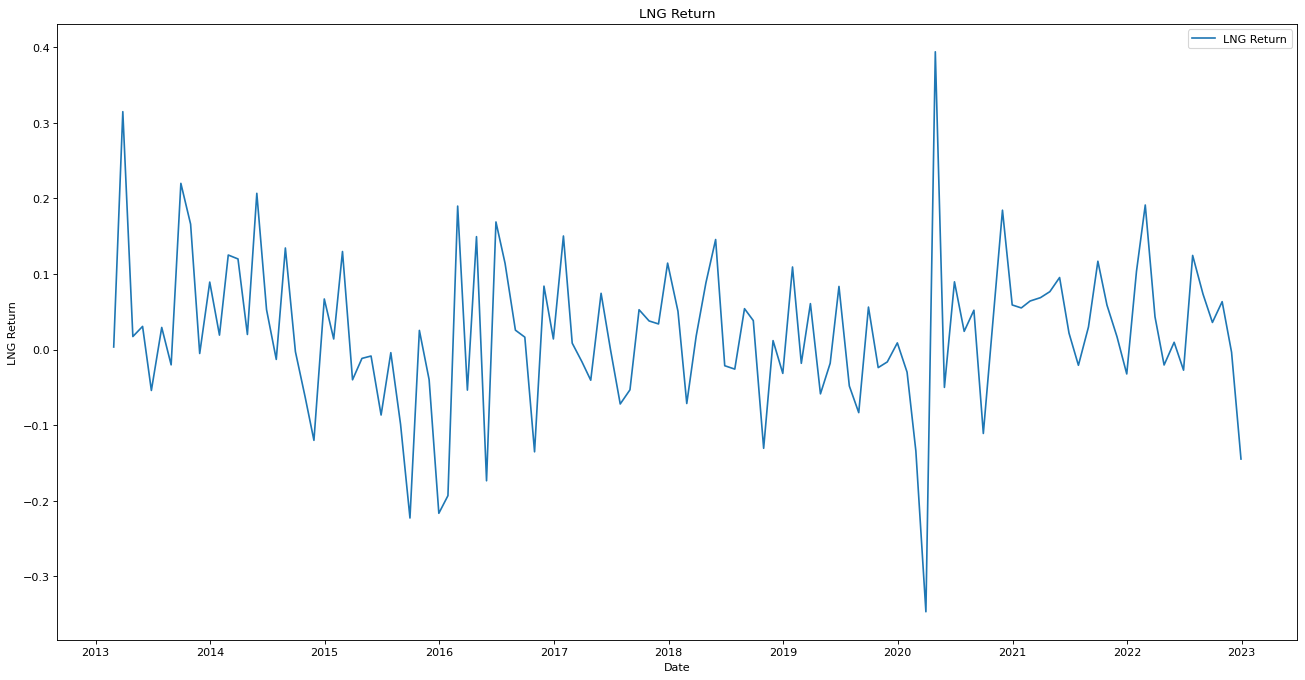

In [ ]:
# plt.figure(figsize=(20, 10), dpi=80)
# plt.plot(df_stocks['date'], df_stocks['LNG'], label = "LNG Return")
# plt.legend()
# plt.xlabel('Date')
# plt.ylabel('LNG Return')
# plt.title('LNG Return')
# plt.savefig("LNG_returns.pdf")

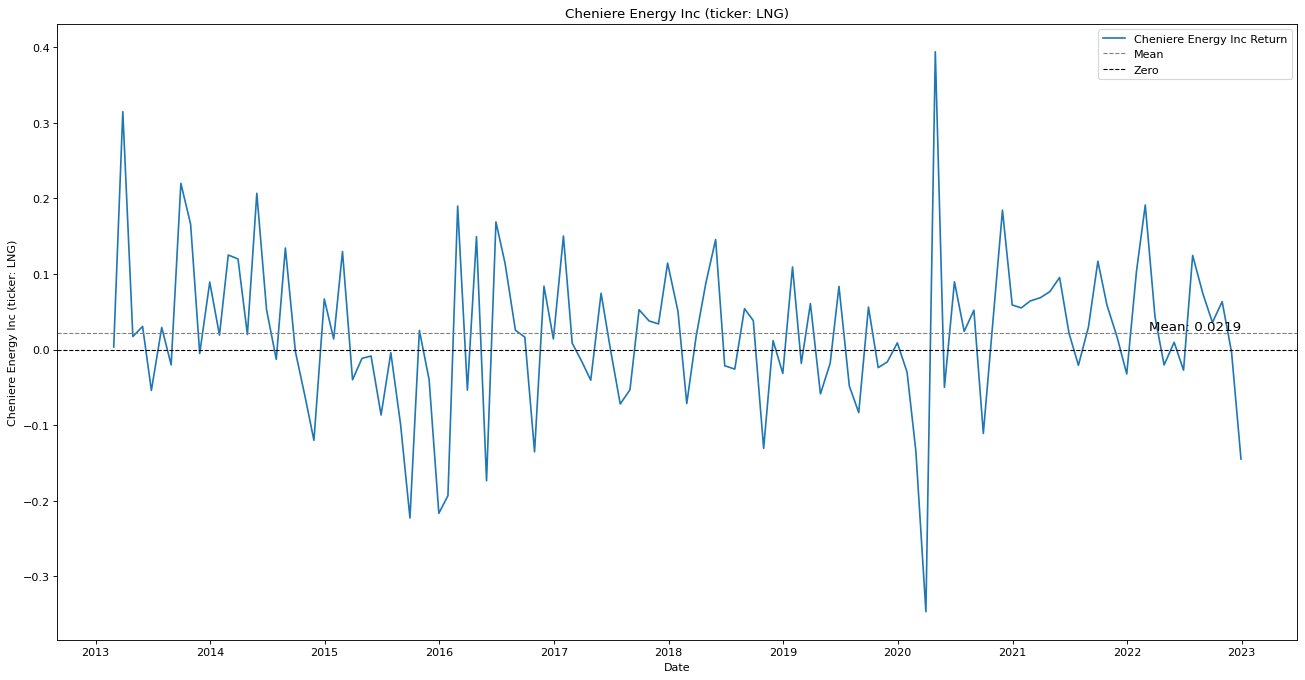

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10), dpi=80)
plt.plot(df_stocks['date'], df_stocks['LNG'], label="Cheniere Energy Inc Return")

# Draw horizontal lines
plt.axhline(y=mu["LNG"], color='grey', linestyle='--', linewidth=1, label='Mean')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1, label='Zero')

# Annotate the mean line
plt.text(df_stocks['date'].iloc[-1], mu["LNG"], f'Mean: {mu["LNG"]:.4f}',
         va='bottom', ha='right', fontsize=12, color='black')

plt.legend()
plt.xlabel('Date')
plt.ylabel('Cheniere Energy Inc (ticker: LNG)')
plt.title('Cheniere Energy Inc (ticker: LNG)')
plt.savefig("LNG.pdf")

### Some simple descriptive stats

In [ ]:
stats_df = df_stocks.describe().transpose()

In [ ]:
stats_df.rename(columns={"count": "N", "mean": "Mean", "std": "St. Dev.", "25%": "Pctl(25)","75%": "Pctl(75)", "50%": "Median"}, inplace=True)

In [ ]:
stats_df = stats_df.iloc[:,[0,1,2,4,5,6]]

In [ ]:
print("Return descriptive stats\n")
print(round(stats_df,1))

Return descriptive stats

          N                           Mean                  min  \
date    119  2018-01-29 04:02:01.008403456  2013-02-28 00:00:00   
ASML  119.0                       0.020561            -0.169609   
BYDE  119.0                        0.03653            -0.385819   
COST  119.0                       0.015897            -0.153454   
LNG   119.0                       0.021899            -0.346851   
MS    119.0                       0.016125            -0.244948   
O     119.0                        0.00946            -0.308012   

                   Median             Pctl(75)                  max  
date  2018-01-31 00:00:00  2020-07-15 12:00:00  2022-12-30 00:00:00  
ASML              0.01314             0.082067             0.239571  
BYDE              0.02782              0.14191             0.727648  
COST             0.021864             0.058243             0.148307  
LNG              0.019016             0.073784             0.393731  
MS               

In [ ]:
# # prompt: make stats_df results to be in the table , and then allow me to download it

# from google.colab import data_table
# from google.colab import files

# # Assuming 'stats_df' is already defined from the previous code

# # Display the DataFrame as an interactive table
# data_table.DataTable(stats_df, include_index=True, num_rows_per_page=10)

# # Allow the user to download the table as a CSV file
# stats_df.to_csv('stats_data.csv', index=True)  # Save to a CSV file
# files.download('stats_data.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Mean vector and covariance matrix

In [ ]:
mu = df_stocks[["O", "LNG", "MS", "COST", "BYDE", "ASML"]].mean(axis=0)
mu


,0
O,0.009460
LNG,0.021899
MS,0.016125
COST,0.015897
BYDE,0.036530
ASML,0.020561


In [ ]:
# prompt: CALCULATE THE MEAN RETURN of the stocks annuanalised from the monthly average returns

# Annualize the mean return
annualized_mean_return = (1 + mu) ** 12 - 1
print("Annualized Mean Return:\n", annualized_mean_return)


Annualized Mean Return:
 O       0.119623
LNG     0.296873
MS      0.211623
COST    0.208365
BYDE    0.538093
ASML    0.276640
dtype: float64


In [ ]:
std_dev = df_stocks[["O", "LNG", "MS", "COST", "BYDE", "ASML"]].std(axis=0)
print(std_dev)

O       0.066433
LNG     0.102519
MS      0.080420
COST    0.056265
BYDE    0.189052
ASML    0.078410
dtype: float64


In [ ]:
# prompt: calculate annualised standard deviation from the monthly sd

# Annualize the standard deviation
annualized_std_dev = std_dev * np.sqrt(12)
print("Annualized Standard Deviation:\n", annualized_std_dev)


Annualized Standard Deviation:
 O       0.230129
LNG     0.355135
MS      0.278584
COST    0.194907
BYDE    0.654895
ASML    0.271620
dtype: float64


In [ ]:
R_f = 0.001

#Calculate the Sharpe ratio for each stock
sharpe_ratios = (mu - R_f) / std_dev

# Print the Sharpe ratios
print(sharpe_ratios)

O       0.127354
LNG     0.203859
MS      0.188079
COST    0.264773
BYDE    0.187938
ASML    0.249474
dtype: float64


In [ ]:
# prompt: create a dtatframe with mu , std_dev and sharpe_ratios and then convert them into the table and download it

# Create a DataFrame with mu, std_dev, and Sharpe ratios
portfolio_stats = pd.DataFrame({
    'mu': mu,
    'std_dev': std_dev,
    'sharpe_ratios': sharpe_ratios
})
portfolio_stats
# # Display the DataFrame as an interactive table
# from google.colab import data_table
# data_table.DataTable(portfolio_stats, include_index=True, num_rows_per_page=10)

# # Allow the user to download the table as a CSV file
# from google.colab import files
# portfolio_stats.to_csv('portfolio_stats.csv', index=True)
# files.download('portfolio_stats.csv')


,mu,std_dev,sharpe_ratios
O,0.009460,0.066433,0.127354
LNG,0.021899,0.102519,0.203859
MS,0.016125,0.080420,0.188079
COST,0.015897,0.056265,0.264773
BYDE,0.036530,0.189052,0.187938
ASML,0.020561,0.078410,0.249474


In [ ]:
Omega = df_stocks[["O", "LNG", "MS", "COST", "BYDE", "ASML"]].cov()
Omega

,O,LNG,MS,COST,BYDE,ASML
O,0.004413,0.001531,0.000760,0.001248,0.000633,0.001089
LNG,0.001531,0.010510,0.003410,0.001179,0.003726,0.001648
MS,0.000760,0.003410,0.006467,0.001200,0.003554,0.003566
COST,0.001248,0.001179,0.001200,0.003166,0.000732,0.001670
BYDE,0.000633,0.003726,0.003554,0.000732,0.035741,0.003865
ASML,0.001089,0.001648,0.003566,0.001670,0.003865,0.006148


In [ ]:
# # prompt: convert omega results into a table and download it

# from google.colab import data_table
# from google.colab import files

# # Assuming 'Omega' is already defined from the previous code

# # Display the DataFrame as an interactive table
# data_table.DataTable(Omega, include_index=True, num_rows_per_page=10)

# # Allow the user to download the table as a CSV file
# Omega.to_csv('omega_data.csv', index=True)  # Save to a CSV file
# files.download('omega_data.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
rho = df_stocks[["O", "LNG", "MS", "COST", "BYDE", "ASML"]].corr()
rho

,O,LNG,MS,COST,BYDE,ASML
O,1.000000,0.224768,0.142328,0.333974,0.050388,0.209082
LNG,0.224768,1.000000,0.413553,0.204373,0.192240,0.204975
MS,0.142328,0.413553,1.000000,0.265204,0.233730,0.565535
COST,0.333974,0.204373,0.265204,1.000000,0.068859,0.378580
BYDE,0.050388,0.192240,0.233730,0.068859,1.000000,0.260744
ASML,0.209082,0.204975,0.565535,0.378580,0.260744,1.000000


In [ ]:
# # prompt: convert rho results into a table and download it

# # Assuming 'rho' is already defined from the previous code

# # Display the DataFrame as an interactive table
# data_table.DataTable(rho, include_index=True, num_rows_per_page=10)

# # Allow the user to download the table as a CSV file
# rho.to_csv('rho_data.csv', index=True)  # Save to a CSV file
# files.download('rho_data.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# mu = df_stocks[["O", "LNG", "MS", "COST", "BYDE", "ASML"]].mean(axis=0)
# std_dev = df_stocks[["O", "LNG", "MS", "COST", "BYDE", "ASML"]].std(axis=0)
# Omega = df_stocks[["O", "LNG", "MS", "COST", "BYDE", "ASML"]].cov()
# rho = df_stocks[["O", "LNG", "MS", "COST", "BYDE", "ASML"]].corr()

### Construct simple portfolio stats

#### Equally weighted

In [ ]:
w = np.array([1/6,1/6,1/6,1/6,1/6,1/6])
w

array([0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
       0.16666667])

In [ ]:
mu_p = np.dot(w.transpose(),mu)
mu_p

np.float64(0.02007895984332614)

In [ ]:
var_p = np.dot(np.dot(w.transpose(),Omega),w) #Finding the variance of the portfolio
var_p

np.float64(0.003501861407407804)

#### Different weights

In [ ]:
#["O", "LNG", "MS", "COST", "BYD", "ASML"]
w = np.array([0.23,0.17,0.15,0.10,0.2,0.15])
w

array([0.23, 0.17, 0.15, 0.1 , 0.2 , 0.15])

In [ ]:
mu_p = np.dot(w.transpose(),mu)
mu_p

np.float64(0.020297517316473033)

In [ ]:
var_p = np.dot(np.dot(w.transpose(),Omega),w)
var_p

np.float64(0.003917664033273743)

In [ ]:
# prompt: compute a sharp ratio for that portfolio

# Assuming 'mu', 'std_dev', and 'R_f' are already defined from the previous code

# Calculate the Sharpe ratio for the portfolio
sharpe_ratio_portfolio = (mu_p - R_f) / np.sqrt(var_p)

print(f"Sharpe Ratio of the portfolio: {sharpe_ratio_portfolio}")


Sharpe Ratio of the portfolio: 0.30831016563067665


In [ ]:
# prompt: combine waiting of this portfolio, with mu and var and np.sqrt of var and sharp and present it in a good way and downlod it

import pandas as pd
from google.colab import files

# Assuming mu, var_p, and sharpe_ratio_portfolio are already defined

# Create a DataFrame for the portfolio statistics
portfolio_summary = pd.DataFrame({
    'Metric': ['Portfolio Return (mu)', 'Portfolio Variance (var_p)', 'Portfolio Standard Deviation (sqrt(var_p))', 'Sharpe Ratio'],
    'Value': [mu_p, var_p, np.sqrt(var_p), sharpe_ratio_portfolio]
})

# Display the DataFrame
print(portfolio_summary)

# Download the DataFrame as a CSV file
portfolio_summary.to_csv('portfolio_summary.csv', index=False)
files.download('portfolio_summary.csv')


                                       Metric     Value
0                       Portfolio Return (mu)  0.020298
1                  Portfolio Variance (var_p)  0.003918
2  Portfolio Standard Deviation (sqrt(var_p))  0.062591
3                                Sharpe Ratio  0.308310


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Rough mean variance frontier

In [ ]:
# n = 100+6-1 k=6-1=5
import math
x = math.comb(105,5)
#y = math.comb(102,2)
print(x)
#print(y)
resMat = np.empty((96560646,8))
resMat[:] = np.nan
resMat

96560646


array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

In [ ]:
resMat.shape

(96560646, 8)

In [ ]:
mySeq = np.arange(0,101) #delete 5
mySeq

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100])

myCount = 0
for i in mySeq:
    tmp = 100-i
    for j in range(tmp+1):
        k = 100-i-j
        w = np.array([i,j,k])/100
        resMat[myCount,0:3] = w.transpose()
        resMat[myCount,4] = np.dot(w.transpose(),mu)
        resMat[myCount,3] = (np.dot(np.dot(w.transpose(),Omega),w))**0.5
        myCount = myCount+1
        # resMAt stores info into the array that we created with 5 columns
        #but with 6 stocks it will have 8 columns

In [ ]:
def generate_allocations(total, stocks, current=[]):
    """Recursively generate all allocations of 'total' into 'stocks' parts."""
    if stocks == 1:
        yield current + [total]
    else:
        for i in range(total + 1):
            yield from generate_allocations(total - i, stocks - 1, current + [i])

myCount = 0
for alloc in generate_allocations(100, 6):
    w = np.array(alloc) / 100
    resMat[myCount, :6] = w
    resMat[myCount, 6] = np.dot(w, mu)
    resMat[myCount, 7] = np.sqrt(np.dot(w, np.dot(Omega, w)))
    myCount += 1


In [ ]:
print(resMat)

[[0.         0.         0.         ... 1.         0.02056119 0.07840986]
 [0.         0.         0.         ... 0.99       0.02072088 0.07814002]
 [0.         0.         0.         ... 0.98       0.02088056 0.0779131 ]
 ...
 [0.99       0.         0.01       ... 0.         0.0095271  0.06588755]
 [0.99       0.01       0.         ... 0.         0.00958484 0.06600627]
 [1.         0.         0.         ... 0.         0.00946045 0.06643261]]


In [ ]:
myCount = 0
for i in mySeq:
    tmp = 100-i
    print(i)
    for j in range(tmp+1):
        k = 100-i-j
        print(k)
        for l in range(k+1):
            m = 100 -i-j-l
            for n in range(m+1):
                o = 100-i-j-l-n
                for p in range(o+1):
                    q = 100 - i - j - l- n - p

                    w = np.array([i,j,l,n,p,q])/100
                    resMat[myCount,0:6] = w.transpose()
                    resMat[myCount,6] = np.dot(w.transpose(),mu)
                    resMat[myCount,7] = (np.dot(np.dot(w.transpose(),Omega),w))**0.5
                    myCount = myCount+1
# resMAt stores info into the array that we created with 5 columns
#but with 6 stocks it will have 8 columns

Выходные данные были обрезаны до нескольких последних строк (5000).
50
49
48
47
46
45
44
43
42
41
40
39
38
37
36
35
34
33
32
31
30
29
28
27
26
25
24
23
22
21
20
19
18
17
16
15
14
13
12
11
10
9
8
7
6
5
4
3
2
1
0
3
97
96
95
94
93
92
91
90
89
88
87
86
85
84
83
82
81
80
79
78
77
76
75
74
73
72
71
70
69
68
67
66
65
64
63
62
61
60
59
58
57
56
55
54
53
52
51
50
49
48
47
46
45
44
43
42
41
40
39
38
37
36
35
34
33
32
31
30
29
28
27
26
25
24
23
22
21
20
19
18
17
16
15
14
13
12
11
10
9
8
7
6
5
4
3
2
1
0
4
96
95
94
93
92
91
90
89
88
87
86
85
84
83
82
81
80
79
78
77
76
75
74
73
72
71
70
69
68
67
66
65
64
63
62
61
60
59
58
57
56
55
54
53
52
51
50
49
48
47
46
45
44
43
42
41
40
39
38
37
36
35
34
33
32
31
30
29
28
27
26
25
24
23
22
21
20
19
18
17
16
15
14
13
12
11
10
9
8
7
6
5
4
3
2
1
0
5
95
94
93
92
91
90
89
88
87
86
85
84
83
82
81
80
79
78
77
76
75
74
73
72
71
70
69
68
67
66
65
64
63
62
61
60
59
58
57
56
55
54
53
52
51
50
49
48
47
46
45
44
43
42
41
40
39
38
37
36
35
34
33
32
31
30
29
28
27
26
25
24
23

In [ ]:
resData = pd.DataFrame(resMat, columns=["w1_O","w2_LNG","w3_MS","w4_Cost","w5_BYDE","w6_ASML","mu_p", "sigma_p"])
resData


,w1_O,w2_LNG,w3_MS,w4_Cost,w5_BYDE,w6_ASML,mu_p,sigma_p
0,0.00,0.00,0.00,0.00,0.00,1.00,0.020561,0.078410
1,0.00,0.00,0.00,0.00,0.01,0.99,0.020721,0.078140
2,0.00,0.00,0.00,0.00,0.02,0.98,0.020881,0.077913
3,0.00,0.00,0.00,0.00,0.03,0.97,0.021040,0.077729
4,0.00,0.00,0.00,0.00,0.04,0.96,0.021200,0.077589
...,...,...,...,...,...,...,...,...
96560641,0.99,0.00,0.00,0.00,0.01,0.00,0.009731,0.065891
96560642,0.99,0.00,0.00,0.01,0.00,0.00,0.009525,0.065958
96560643,0.99,0.00,0.01,0.00,0.00,0.00,0.009527,0.065888
96560644,0.99,0.01,0.00,0.00,0.00,0.00,0.009585,0.066006


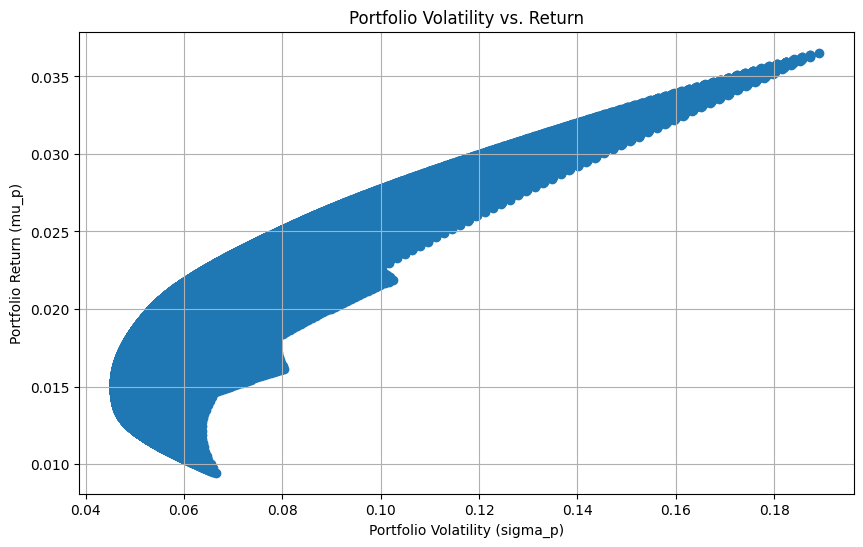

In [ ]:
# prompt: plot the scatter graph of resData mu_p on sigma_p

plt.figure(figsize=(10, 6))
plt.scatter(resData['sigma_p'], resData['mu_p'])
plt.xlabel('Portfolio Volatility (sigma_p)')
plt.ylabel('Portfolio Return (mu_p)')
plt.title('Portfolio Volatility vs. Return')
plt.grid(True)
plt.show()


In [ ]:
# prompt: sort from highest to lowest sigma_p in resData

resData_sorted = resData.sort_values(by='sigma_p', ascending=False)
resData_sorted


In [ ]:
resData_sorted2 = resData.sort_values(by='mu_p', ascending=False)
resData_sorted2


,w1_O,w2_LNG,w3_MS,w4_Cost,w5_BYDE,w6_ASML,mu_p,sigma_p
100,0.00,0.00,0.00,0.00,1.00,0.00,0.036530,0.189052
176950,0.00,0.01,0.00,0.00,0.99,0.00,0.036384,0.187361
99,0.00,0.00,0.00,0.00,0.99,0.01,0.036370,0.187367
5250,0.00,0.00,0.01,0.00,0.99,0.00,0.036326,0.187351
200,0.00,0.00,0.00,0.01,0.99,0.00,0.036324,0.187201
...,...,...,...,...,...,...,...,...
96560644,0.99,0.01,0.00,0.00,0.00,0.00,0.009585,0.066006
96560640,0.99,0.00,0.00,0.00,0.00,0.01,0.009571,0.065937
96560643,0.99,0.00,0.01,0.00,0.00,0.00,0.009527,0.065888
96560642,0.99,0.00,0.00,0.01,0.00,0.00,0.009525,0.065958


In [ ]:
# df_sample = resData
# df_sample.head(100)
# df_sample.to_csv("data.csv", index=False)

In [ ]:

print(f"Log Risk-Free Rate: {rf_log:.6f}")

sharpe_ratios = []

for i in range(len(resData)):  # Iterate over all rows
    muOfP = resData.loc[i, 'mu_p']
    sigmaOfP = resData.loc[i, 'sigma_p']

    if sigmaOfP != 0:  # Avoid division by zero
        sharpe_ratio = (muOfP - R_f) / sigmaOfP
    else:
        sharpe_ratio = None  # Assign None (or float('nan')) if sigma is zero

    sharpe_ratios.append(sharpe_ratio)

# Create DataFrame after the loop
df_sharpe = pd.DataFrame({'Sharpe Ratio': sharpe_ratios})

# Print results
print(df_sharpe)




Log Risk-Free Rate: 0.001000
          Sharpe Ratio
0             3.764854
1             3.794104
2             4.593563
3             5.372356
4             6.018251
...                ...
96560641      5.822087
96560642      6.819900
96560643      6.810839
96560644      6.782197
96560645      6.916436

[96560646 rows x 1 columns]


In [ ]:

# # Combine the DataFrames
df_portfolios = pd.concat([resData, df_sharpe], axis=1)

# Print the combined DataFrame
df_portfolios

,w1_O,w2_LNG,w3_MS,w4_Cost,w5_BYDE,w6_ASML,sigma_p,mu_p
0,0.00,0.00,0.00,0.00,0.00,1.00,0.020561,0.078410
1,0.00,0.00,0.00,0.00,0.01,0.99,0.020721,0.078140
2,0.00,0.00,0.00,0.00,0.02,0.98,0.020881,0.077913
3,0.00,0.00,0.00,0.00,0.03,0.97,0.021040,0.077729
4,0.00,0.00,0.00,0.00,0.04,0.96,0.021200,0.077589
...,...,...,...,...,...,...,...,...
96560641,0.99,0.00,0.00,0.00,0.01,0.00,0.009731,0.065891
96560642,0.99,0.00,0.00,0.01,0.00,0.00,0.009525,0.065958
96560643,0.99,0.00,0.01,0.00,0.00,0.00,0.009527,0.065888
96560644,0.99,0.01,0.00,0.00,0.00,0.00,0.009585,0.066006


### **From the GOOGLE drive data**

In [ ]:
df_portfolios = pd.read_csv("/content/drive/MyDrive/dataP.csv")
df_portfolios


,w1_O,w2_LNG,w3_MS,w4_Cost,w5_BYDE,w6_ASML,mu_p,sigma_p,Sharpe Ratio
0,0.00,0.00,0.00,0.00,0.00,1.00,0.020561,0.078410,0.249474
1,0.00,0.00,0.00,0.00,0.01,0.99,0.020721,0.078140,0.252379
2,0.00,0.00,0.00,0.00,0.02,0.98,0.020881,0.077913,0.255163
3,0.00,0.00,0.00,0.00,0.03,0.97,0.021040,0.077729,0.257820
4,0.00,0.00,0.00,0.00,0.04,0.96,0.021200,0.077589,0.260344
...,...,...,...,...,...,...,...,...,...
96560641,0.99,0.00,0.00,0.00,0.01,0.00,0.009731,0.065891,0.132510
96560642,0.99,0.00,0.00,0.01,0.00,0.00,0.009525,0.065958,0.129246
96560643,0.99,0.00,0.01,0.00,0.00,0.00,0.009527,0.065888,0.129419
96560644,0.99,0.01,0.00,0.00,0.00,0.00,0.009585,0.066006,0.130061


In [ ]:
# prompt: sort the data in the df_portfolios from the highest to lowest of  the sharp ratio
# Portfolio S
# Sort the DataFrame by the 'Sharpe Ratio' column in descending order
df_portfolios_sorted_S = df_portfolios.sort_values(by='Sharpe Ratio', ascending=False)

# Display the sorted DataFrame
df_portfolios_sorted_S


,w1_O,w2_LNG,w3_MS,w4_Cost,w5_BYDE,w6_ASML,mu_p,sigma_p,Sharpe Ratio
11247008,0.02,0.17,0.00,0.48,0.09,0.24,0.019765,0.052740,0.355803
11247042,0.02,0.17,0.00,0.49,0.09,0.23,0.019719,0.052610,0.355797
11247009,0.02,0.17,0.00,0.48,0.10,0.23,0.019925,0.053191,0.355793
6898747,0.01,0.17,0.00,0.49,0.10,0.23,0.019989,0.053372,0.355790
6898746,0.01,0.17,0.00,0.49,0.09,0.24,0.019830,0.052924,0.355784
...,...,...,...,...,...,...,...,...,...
96560644,0.99,0.01,0.00,0.00,0.00,0.00,0.009585,0.066006,0.130061
96560640,0.99,0.00,0.00,0.00,0.00,0.01,0.009571,0.065937,0.129995
96560643,0.99,0.00,0.01,0.00,0.00,0.00,0.009527,0.065888,0.129419
96560642,0.99,0.00,0.00,0.01,0.00,0.00,0.009525,0.065958,0.129246


In [ ]:
# prompt: sort the data in the df_portfolios from the lowest to highest the Risk (Standard deviation)
# Portfolio M
# Sort the DataFrame by the 'Sharpe Ratio' column in descending order
df_portfolios_sorted_M = df_portfolios.sort_values(by='sigma_p', ascending=True)

# Display the sorted DataFrame
df_portfolios_sorted_M

,w1_O,w2_LNG,w3_MS,w4_Cost,w5_BYDE,w6_ASML,mu_p,sigma_p,Sharpe Ratio
78410467,0.29,0.05,0.13,0.44,0.02,0.07,0.015100,0.045808,0.307799
78411908,0.29,0.05,0.14,0.44,0.02,0.06,0.015055,0.045808,0.306826
78358073,0.29,0.04,0.14,0.44,0.02,0.07,0.015042,0.045810,0.306524
79562534,0.30,0.04,0.14,0.44,0.02,0.06,0.014931,0.045811,0.304095
78411898,0.29,0.05,0.14,0.43,0.02,0.07,0.015102,0.045811,0.307827
...,...,...,...,...,...,...,...,...,...
200,0.00,0.00,0.00,0.01,0.99,0.00,0.036324,0.187201,0.188694
5250,0.00,0.00,0.01,0.00,0.99,0.00,0.036326,0.187351,0.188555
176950,0.00,0.01,0.00,0.00,0.99,0.00,0.036384,0.187361,0.188853
99,0.00,0.00,0.00,0.00,0.99,0.01,0.036370,0.187367,0.188775


### From your set of portfolios, recommend a portfolio containing only stock to each of the following investors. In each case describe the portfolio weights and the resulting portfolio return statistics and give some intuition as to why the weights take the values that they do. Also mark the location of the portfolio on the plot you created above.
o An investor who simply wants to minimise risk. Call her portfolio M.
o An investor who wants to maximise Sharpe ratio. Call her portfolio S.

In [ ]:
# prompt: select the first row from the df_portfolios_sorted_M and put it inside a table all these values

S_port = df_portfolios_sorted_S.iloc[0]

print("An investor who wants to maximise Sharpe ratio. Portfolio S:")
print(S_port)

An investor who wants to maximise Sharpe ratio. Portfolio S:
w1_O            0.020000
w2_LNG          0.170000
w3_MS           0.000000
w4_Cost         0.480000
w5_BYDE         0.090000
w6_ASML         0.240000
mu_p            0.019765
sigma_p         0.052740
Sharpe Ratio    0.355803
Name: 11247008, dtype: float64


In [ ]:
# prompt: present S_port into a table and download it

# Display the DataFrame as an interactive table
from google.colab import data_table
data_table.DataTable(S_port.to_frame(), include_index=True, num_rows_per_page=10)

# Allow the user to download the table as a CSV file
from google.colab import files
S_port.to_csv('S_port.csv', index=True)
files.download('S_port.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
M_port = df_portfolios_sorted_M.iloc[0]

print("An investor who simply wants to minimise risk. Portfolio M:")
print(M_port)

An investor who simply wants to minimise risk. Portfolio M:
w1_O            0.290000
w2_LNG          0.050000
w3_MS           0.130000
w4_Cost         0.440000
w5_BYDE         0.020000
w6_ASML         0.070000
mu_p            0.015100
sigma_p         0.045808
Sharpe Ratio    0.307799
Name: 78410467, dtype: float64


In [ ]:
# prompt:  present M_port into a table and download it

# Display the DataFrame as an interactive table
data_table.DataTable(M_port.to_frame(), include_index=True, num_rows_per_page=10)

# Allow the user to download the table as a CSV file
M_port.to_csv('M_port.csv', index=True)
files.download('M_port.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Visualisation

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


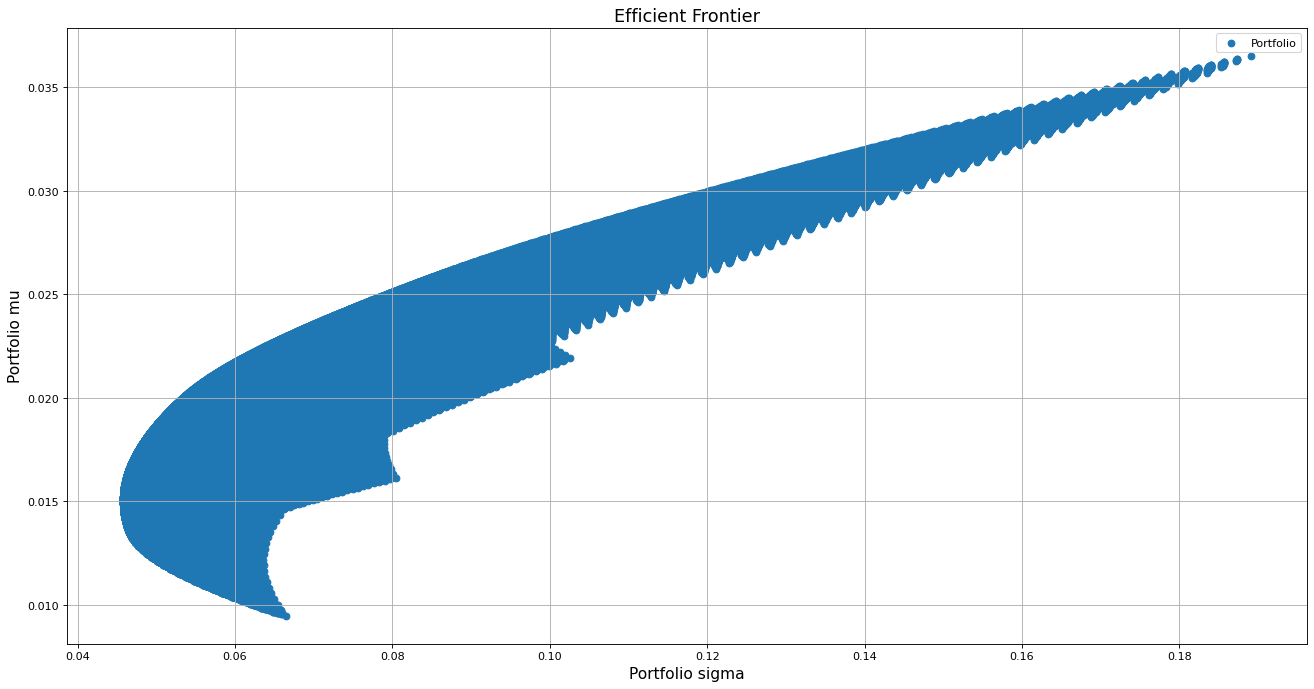

In [ ]:
plt.figure(figsize=(20, 10), dpi=80)

# Scatter plot for the portfolio (using all data points)
plt.scatter(df_portfolios['sigma_p'], df_portfolios['mu_p'], label="Portfolio")

plt.xlabel('Portfolio sigma', fontsize=14)
plt.ylabel('Portfolio mu', fontsize=14)
plt.title('Efficient Frontier', fontsize=16)
plt.grid(True)
plt.legend()

# Annotation for stocks
plt.annotate(df_stocks.columns[1],
             xy=(df_stocks[df_stocks.columns[1]].std() + 0.15, df_stocks[df_stocks.columns[1]].mean()),
             xytext=(df_stocks[df_stocks.columns[1]].std() + 0.15, df_stocks[df_stocks.columns[1]].mean()),
             color='black',
             fontsize=16)

plt.annotate(df_stocks.columns[2],
             xy=(df_stocks[df_stocks.columns[2]].std() + 0.15, df_stocks[df_stocks.columns[2]].mean()),
             xytext=(df_stocks[df_stocks.columns[2]].std() + 0.15, df_stocks[df_stocks.columns[2]].mean()),
             color='black',
             fontsize=16)

plt.annotate(df_stocks.columns[3],
             xy=(df_stocks[df_stocks.columns[3]].std() + 0.15, df_stocks[df_stocks.columns[3]].mean()),
             xytext=(df_stocks[df_stocks.columns[3]].std() + 0.15, df_stocks[df_stocks.columns[3]].mean()),
             color='black',
             fontsize=10)

plt.annotate(df_stocks.columns[4],
             xy=(df_stocks[df_stocks.columns[4]].std() + 0.15, df_stocks[df_stocks.columns[4]].mean()),
             xytext=(df_stocks[df_stocks.columns[4]].std() + 0.15, df_stocks[df_stocks.columns[4]].mean()),
             color='black',
             fontsize=10)

plt.annotate(df_stocks.columns[5],
             xy=(df_stocks[df_stocks.columns[5]].std() + 0.15, df_stocks[df_stocks.columns[5]].mean()),
             xytext=(df_stocks[df_stocks.columns[5]].std() + 0.15, df_stocks[df_stocks.columns[5]].mean()),
             color='black',
             fontsize=10)

plt.annotate(df_stocks.columns[6],
             xy=(df_stocks[df_stocks.columns[6]].std() + 0.15, df_stocks[df_stocks.columns[6]].mean()),
             xytext=(df_stocks[df_stocks.columns[6]].std() + 0.15, df_stocks[df_stocks.columns[6]].mean()),
             color='black',
             fontsize=10)

plt.show()


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


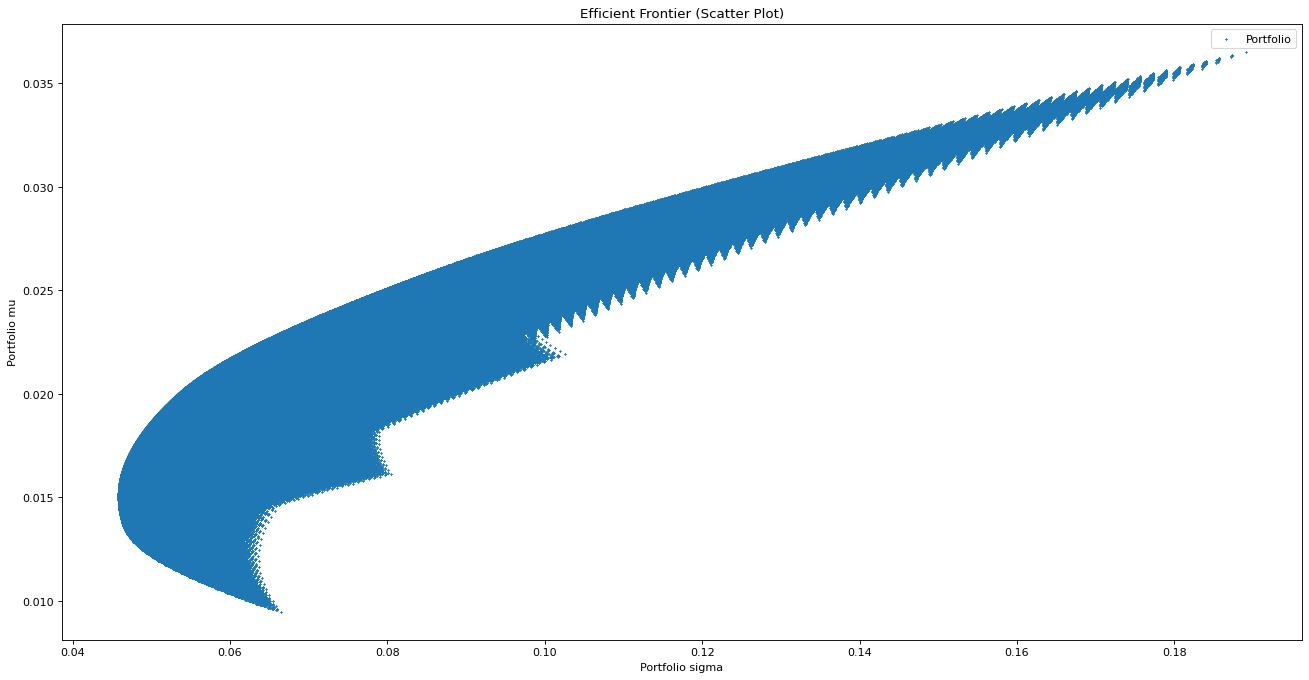

In [ ]:
# prompt: i want instead of dots on my graph small crosses and i want to increase dimension

# plt.figure(figsize=(20, 10), dpi=80)
# plt.scatter(df_portfolio['sigma_p'][::1], df_portfolio['mu_p'][::1], marker='x', s=2, label="Portfolio")  # Use 'x' for small crosses and increase size with 's'
# plt.legend()
# plt.xlabel('Portfolio sigma')
# plt.ylabel('Portfolio mu')
# plt.title('Efficient Frontier (Scatter Plot)')
# plt.show()


plt.figure(figsize=(20, 10), dpi=80)  # Increase figure size for better visibility

plt.scatter(
    df_portfolios['sigma_p'],  # X-axis: Portfolio standard deviation (risk)
    df_portfolios['mu_p'],     # Y-axis: Portfolio expected return
    marker='x',  # Change marker style to small crosses ('x')
    s=1,        # Increase marker size for better visibility
    label="Portfolio"
)

# Annotate a specific stock on the graph
plt.annotate(
    df_stocks.columns[1],  # Stock name from dataframe columns
    xy=((df_stocks[df_stocks.columns[1]].var()**0.5) + 0.15, df_stocks[df_stocks.columns[1]].mean()),  # Arrow position (x, y)
    xytext=((df_stocks[df_stocks.columns[1]].var()**0.5) + 0.15, df_stocks[df_stocks.columns[1]].mean()),  # Text position (x, y)
    color='black',  # Text color
    fontsize=16  # Text size
)

plt.legend()  # Add a legend to distinguish different data points
plt.xlabel('Portfolio sigma')  # Label for x-axis
plt.ylabel('Portfolio mu')     # Label for y-axis
plt.title('Efficient Frontier (Scatter Plot)')  # Title of the plot
plt.show()  # Display the plot



In [ ]:
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
selected_columns = ["w1_O","w2_LNG","w3_MS","w4_Cost","w5_BYDE","w6_ASML"]
portfolios = np.array(df_portfolios[selected_columns])
print(portfolios)

# Convert lists to numpy arrays for easy plotting
expected_returns = np.array(df_portfolios['mu_p'])
print(expected_returns)
portfolio_std_devs = np.array(df_portfolios['sigma_p'])
print(portfolio_std_devs)
sharpe_ratios = np.array(df_portfolios['Sharpe Ratio'])
print(sharpe_ratios)

portfolio_df = df_portfolios
print(portfolio_df.head())


[[0.   0.   0.   0.   0.   1.  ]
 [0.   0.   0.   0.   0.01 0.99]
 [0.   0.   0.   0.   0.02 0.98]
 ...
 [0.99 0.   0.01 0.   0.   0.  ]
 [0.99 0.01 0.   0.   0.   0.  ]
 [1.   0.   0.   0.   0.   0.  ]]
[0.02056119 0.02072088 0.02088056 ... 0.0095271  0.00958484 0.00946045]
[0.07840986 0.07814002 0.0779131  ... 0.06588755 0.06600627 0.06643261]
[0.24947355 0.25237867 0.25516329 ... 0.12941899 0.13006097 0.12735389]
   w1_O  w2_LNG  w3_MS  w4_Cost  w5_BYDE  w6_ASML      mu_p   sigma_p  \
0   0.0     0.0    0.0      0.0     0.00     1.00  0.020561  0.078410   
1   0.0     0.0    0.0      0.0     0.01     0.99  0.020721  0.078140   
2   0.0     0.0    0.0      0.0     0.02     0.98  0.020881  0.077913   
3   0.0     0.0    0.0      0.0     0.03     0.97  0.021040  0.077729   
4   0.0     0.0    0.0      0.0     0.04     0.96  0.021200  0.077589   

   Sharpe Ratio  
0      0.249474  
1      0.252379  
2      0.255163  
3      0.257820  
4      0.260344  


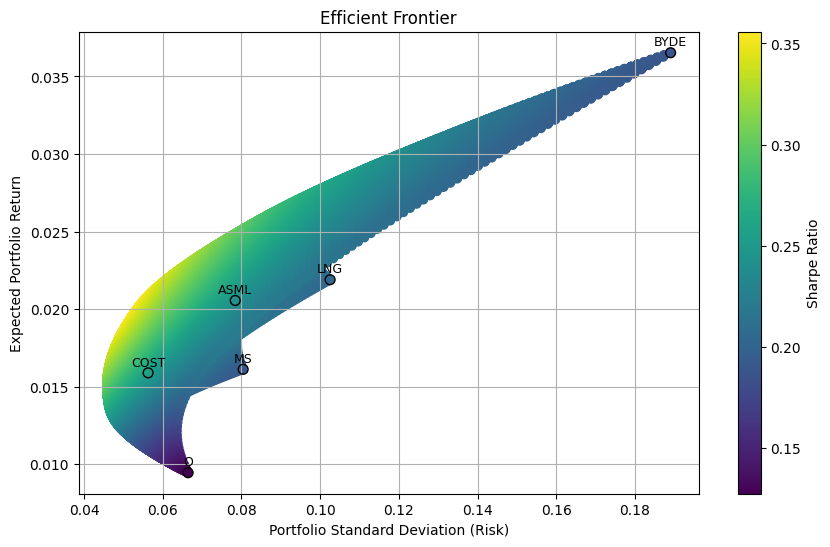

Best portfolio (highest Sharpe ratio):
Expected Return: 0.0197652273563822
Standard Deviation: 0.0527404251660288
Sharpe Ratio: 0.3558034903455673


In [ ]:

# Plotting the efficient frontier (Expected return vs Portfolio Standard Deviation)
plt.figure(figsize=(10, 6))
plt.scatter(portfolio_std_devs, expected_returns, c=sharpe_ratios, cmap='viridis', marker='o')
plt.colorbar(label='Sharpe Ratio')  # Color bar to represent Sharpe ratio
plt.xlabel('Portfolio Standard Deviation (Risk)')
plt.ylabel('Expected Portfolio Return')
plt.title('Efficient Frontier')

# Add stock names to the points where the weight is 1 for each stock
for i, stock in enumerate(mu.index):  # mu.index contains the stock names
    # Find the portfolios where stock i has weight 1
    stock_weights = portfolios[:, i]
    for j, weight in enumerate(stock_weights):
        if weight == 1:
            # Annotate the plot with only the stock name (no mean return)
            plt.annotate(f'{stock}', (portfolio_std_devs[j], expected_returns[j]),
                         textcoords="offset points", xytext=(0, 5), ha='center', fontsize=9)
            # Plot the point with a black border, same size as other points, no red filling
            plt.scatter(portfolio_std_devs[j], expected_returns[j], c='none', edgecolors='black', s=50, zorder=5)

plt.grid(True)
plt.show()

# Optionally, print the best portfolio (highest Sharpe ratio)
max_sharpe_idx = np.argmax(sharpe_ratios)
print(f"Best portfolio (highest Sharpe ratio):\nExpected Return: {expected_returns[max_sharpe_idx]}")
print(f"Standard Deviation: {portfolio_std_devs[max_sharpe_idx]}")
print(f"Sharpe Ratio: {sharpe_ratios[max_sharpe_idx]}")

# no need

In [ ]:
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt

# Select specific columns
selected_columns = ["w1_O","w2_LNG","w3_MS","w4_Cost","w5_BYDE","w6_ASML"]
portfolios = np.array(df_portfolios[selected_columns])

# # Generate all possible portfolios (weights sum to 100)
# n_stocks = 6
# increments = range(101)  # now weights go from 0 to 100
# combinations = []

# # Generate all combinations of n_stocks weights from 0 to 100, ensuring the sum equals 100
# for comb in itertools.product(increments, repeat=n_stocks):
#     if sum(comb) == 100:  # Ensure the sum of weights is 100 (1.0 in decimal form)
#         combinations.append(comb)

# # Convert combinations to portfolio weights (i.e., divide each by 100 to get weights between 0 and 1)
# portfolios = np.array(combinations) / 100.0

# # Calculate expected returns, portfolio standard deviation and Sharpe ratio for each portfolio
# expected_returns = []
# portfolio_std_devs = []
# sharpe_ratios = []

# # Risk-free rate (you can adjust this value based on your assumptions)
# rf = 0.001

# # Loop through all portfolios to calculate return, risk and Sharpe ratio
# for weights in portfolios:
#     # Expected portfolio return
#     portfolio_return = np.dot(weights, mu)

#     # Portfolio standard deviation (risk)
#     portfolio_std = np.sqrt(np.dot(weights.T, np.dot(Omega, weights)))

#     # Sharpe ratio
#     sharpe_ratio = (portfolio_return - rf) / portfolio_std if portfolio_std != 0 else 0

#     expected_returns.append(portfolio_return)
#     portfolio_std_devs.append(portfolio_std)
#     sharpe_ratios.append(sharpe_ratio)

# Convert lists to numpy arrays for easy plotting
expected_returns = np.array(df_portfolios['mu_p'])
print(expected_returns)
portfolio_std_devs = np.array(df_portfolios['sigma_p'])
print(portfolio_std_devs)
sharpe_ratios = np.array(df_portfolios['Sharpe Ratio'])
print(sharpe_ratios)

portfolio_df = df_portfolios
# # Create a DataFrame to display the portfolio details
# portfolio_df = pd.DataFrame(portfolios, columns=[f'w{i+1}' for i in range(n_stocks)])

# # Add the standard deviation and expected return to the DataFrame
# portfolio_df['sigma_p'] = portfolio_std_devs
# portfolio_df['mu_p'] = expected_returns

# Display the first few rows of the DataFrame
print(portfolio_df.head())

# Plotting the efficient frontier (Expected return vs Portfolio Standard Deviation)
plt.figure(figsize=(10, 6))
plt.scatter(portfolio_std_devs, expected_returns, c=sharpe_ratios, cmap='viridis', marker='o')
plt.colorbar(label='Sharpe Ratio')  # Color bar to represent Sharpe ratio
plt.xlabel('Portfolio Standard Deviation (Risk)')
plt.ylabel('Expected Portfolio Return')
plt.title('Efficient Frontier')

# Add stock names to the points where the weight is 1 for each stock
for i, stock in enumerate(mu.index):  # mu.index contains the stock names
    # Find the portfolios where stock i has weight 1
    stock_weights = portfolios[:, i]
    for j, weight in enumerate(stock_weights):
        if weight == 1:
            # Annotate the plot with only the stock name (no mean return)
            plt.annotate(f'{stock}', (portfolio_std_devs[j], expected_returns[j]),
                         textcoords="offset points", xytext=(0, 5), ha='center', fontsize=9)
            # Plot the point with a black border, same size as other points, no red filling
            plt.scatter(portfolio_std_devs[j], expected_returns[j], c='none', edgecolors='black', s=50, zorder=5)

plt.grid(True)
plt.show()

# Optionally, print the best portfolio (highest Sharpe ratio)
max_sharpe_idx = np.argmax(sharpe_ratios)
print(f"Best portfolio (highest Sharpe ratio):\nExpected Return: {expected_returns[max_sharpe_idx]}")
print(f"Standard Deviation: {portfolio_std_devs[max_sharpe_idx]}")
print(f"Sharpe Ratio: {sharpe_ratios[max_sharpe_idx]}")

### Mathematical frontier

In [ ]:
mu = df_stocks[["O", "LNG", "MS", "COST", "BYDE", "ASML"]].mean(axis=0)
std_dev = df_stocks[["O", "LNG", "MS", "COST", "BYDE", "ASML"]].std(axis=0)
Omega = df_stocks[["O", "LNG", "MS", "COST", "BYDE", "ASML"]].cov()
rho = df_stocks[["O", "LNG", "MS", "COST", "BYDE", "ASML"]].corr()

In [ ]:
onesVec = np.empty((1,6))
onesVec[:] = 1
onesVec
#increase dimension to 6

array([[1., 1., 1., 1., 1., 1.]])

In [ ]:
print(Omega)
print(mu)
print(onesVec)

             O       LNG        MS      COST      BYDE      ASML
O     0.004413  0.001531  0.000760  0.001248  0.000633  0.001089
LNG   0.001531  0.010510  0.003410  0.001179  0.003726  0.001648
MS    0.000760  0.003410  0.006467  0.001200  0.003554  0.003566
COST  0.001248  0.001179  0.001200  0.003166  0.000732  0.001670
BYDE  0.000633  0.003726  0.003554  0.000732  0.035741  0.003865
ASML  0.001089  0.001648  0.003566  0.001670  0.003865  0.006148
O       0.009460
LNG     0.021899
MS      0.016125
COST    0.015897
BYDE    0.036530
ASML    0.020561
dtype: float64
[[1. 1. 1. 1. 1. 1.]]


In [ ]:
A = np.dot(np.dot(onesVec,np.linalg.inv(Omega)),mu)[0]
A

np.float64(7.160022561144786)

In [ ]:
B = np.dot(np.dot(mu.transpose(),np.linalg.inv(Omega)),mu)
B

np.float64(0.14057310158942787)

In [ ]:
F = float(np.dot(np.dot(onesVec,np.linalg.inv(Omega)),onesVec.transpose()))
F

<ipython-input-41-910a00ff7651>:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  F = float(np.dot(np.dot(onesVec,np.linalg.inv(Omega)),onesVec.transpose()))


476.6366718705518

In [ ]:
D = B*F-A**2
D

np.float64(15.736372220003538)

In [ ]:
alpha_0 = (np.dot((B*np.linalg.inv(Omega)),onesVec.transpose()).reshape(6) - np.dot((A*np.linalg.inv(Omega)),mu.transpose()))/D
alpha_0

array([ 1.12960698, -0.34656551,  0.62781089,  0.28705273, -0.21506753,
       -0.48283756])

In [ ]:
alpha_1 = (np.dot((F*np.linalg.inv(Omega)),mu) - np.dot((A*np.linalg.inv(Omega)),onesVec.transpose().reshape(6)))/D
alpha_1

array([-55.72346174,  26.14341138, -32.65325694,  10.09994832,
        15.57449286,  36.55886613])

In [ ]:
rbarVec = np.arange(0.01,0.05,0.001) #rbar is the expected return target
rbarVec #These are all different C
#So for each of these target returns i can create a coreesponding portfolio with the weight and find the standard deviation

array([0.01 , 0.011, 0.012, 0.013, 0.014, 0.015, 0.016, 0.017, 0.018,
       0.019, 0.02 , 0.021, 0.022, 0.023, 0.024, 0.025, 0.026, 0.027,
       0.028, 0.029, 0.03 , 0.031, 0.032, 0.033, 0.034, 0.035, 0.036,
       0.037, 0.038, 0.039, 0.04 , 0.041, 0.042, 0.043, 0.044, 0.045,
       0.046, 0.047, 0.048, 0.049])

In [ ]:
stdVec = np.empty((len(rbarVec),1))
stdVec[:] = np.nan
# print(stdVec)

In [ ]:
for i in range(len(rbarVec)):
    rbar = rbarVec[i] # This is the expected return
    w = alpha_0 + alpha_1*rbar # The optimal portfolio weights for an investor
    #trying to hit an expected return target of C with minimal risk
    print(w)
    stdVec[i] = (np.dot(np.dot(w.transpose(),Omega),w))**0.5

[ 0.57237237 -0.08513139  0.30127832  0.38805221 -0.05932261 -0.1172489 ]
[ 0.51664891 -0.05898798  0.26862507  0.39815216 -0.04374811 -0.08069004]
[ 0.46092544 -0.03284457  0.23597181  0.40825211 -0.02817362 -0.04413117]
[ 0.40520198 -0.00670116  0.20331855  0.41835205 -0.01259913 -0.0075723 ]
[0.34947852 0.01944225 0.1706653  0.428452   0.00297537 0.02898656]
[0.29375506 0.04558566 0.13801204 0.43855195 0.01854986 0.06554543]
[0.2380316  0.07172907 0.10535878 0.4486519  0.03412435 0.10210429]
[0.18230814 0.09787249 0.07270553 0.45875185 0.04969884 0.13866316]
[0.12658467 0.1240159  0.04005227 0.4688518  0.06527334 0.17522203]
[0.07086121 0.15015931 0.00739901 0.47895174 0.08084783 0.21178089]
[ 0.01513775  0.17630272 -0.02525425  0.48905169  0.09642232  0.24833976]
[-0.04058571  0.20244613 -0.0579075   0.49915164  0.11199682  0.28489862]
[-0.09630917  0.22858954 -0.09056076  0.50925159  0.12757131  0.32145749]
[-0.15203264  0.25473295 -0.12321402  0.51935154  0.1431458   0.35801636]


In [ ]:
import numpy as np
import pandas as pd


weights_list = []
std_list = []

for i in range(len(rbarVec)):
    rbar = rbarVec[i]
    w = alpha_0 + alpha_1 * rbar  # Compute optimal weights
    std = (np.dot(np.dot(w.T, Omega), w))**0.5  # Portfolio standard deviation
    weights_list.append(w.flatten())  # Flatten in case w is a 2D array
    std_list.append(std)

    print(f"r̄ = {rbar:.4f}, Weights = {w.flatten()}, Std Dev = {std:.4f}")

# Convert to DataFrame
df_results_MF = pd.DataFrame(weights_list, columns=[f'Weight_{i+1}' for i in range(len(weights_list[0]))])
df_results_MF['Expected Return'] = rbarVec
df_results_MF['Standard Deviation'] = std_list

# Print final DataFrame
print("\nFinal Results:")
print(df_results_MF)


r̄ = 0.0100, Weights = [ 0.57237237 -0.08513139  0.30127832  0.38805221 -0.05932261 -0.1172489 ], Std Dev = 0.0535
r̄ = 0.0110, Weights = [ 0.51664891 -0.05898798  0.26862507  0.39815216 -0.04374811 -0.08069004], Std Dev = 0.0509
r̄ = 0.0120, Weights = [ 0.46092544 -0.03284457  0.23597181  0.40825211 -0.02817362 -0.04413117], Std Dev = 0.0487
r̄ = 0.0130, Weights = [ 0.40520198 -0.00670116  0.20331855  0.41835205 -0.01259913 -0.0075723 ], Std Dev = 0.0471
r̄ = 0.0140, Weights = [0.34947852 0.01944225 0.1706653  0.428452   0.00297537 0.02898656], Std Dev = 0.0461
r̄ = 0.0150, Weights = [0.29375506 0.04558566 0.13801204 0.43855195 0.01854986 0.06554543], Std Dev = 0.0458
r̄ = 0.0160, Weights = [0.2380316  0.07172907 0.10535878 0.4486519  0.03412435 0.10210429], Std Dev = 0.0461
r̄ = 0.0170, Weights = [0.18230814 0.09787249 0.07270553 0.45875185 0.04969884 0.13866316], Std Dev = 0.0471
r̄ = 0.0180, Weights = [0.12658467 0.1240159  0.04005227 0.4688518  0.06527334 0.17522203], Std Dev = 0.

In [ ]:
stdVec.shape


(40, 1)

In [ ]:
theoryData_dict = {"C":list(rbarVec), "sigma_P":list(stdVec.reshape(40,))}
theoryData = pd.DataFrame(theoryData_dict)
theoryData

,C,sigma_P
0,0.010,0.053497
1,0.011,0.050872
2,0.012,0.048730
3,0.013,0.047137
4,0.014,0.046148
5,0.015,0.045804
6,0.016,0.046119
7,0.017,0.047080
8,0.018,0.048648
9,0.019,0.050768


In [ ]:
theoryData_negC = theoryData[theoryData['C']<0.0151]
theoryData_posC = theoryData[theoryData['C'] >= 0.0151]

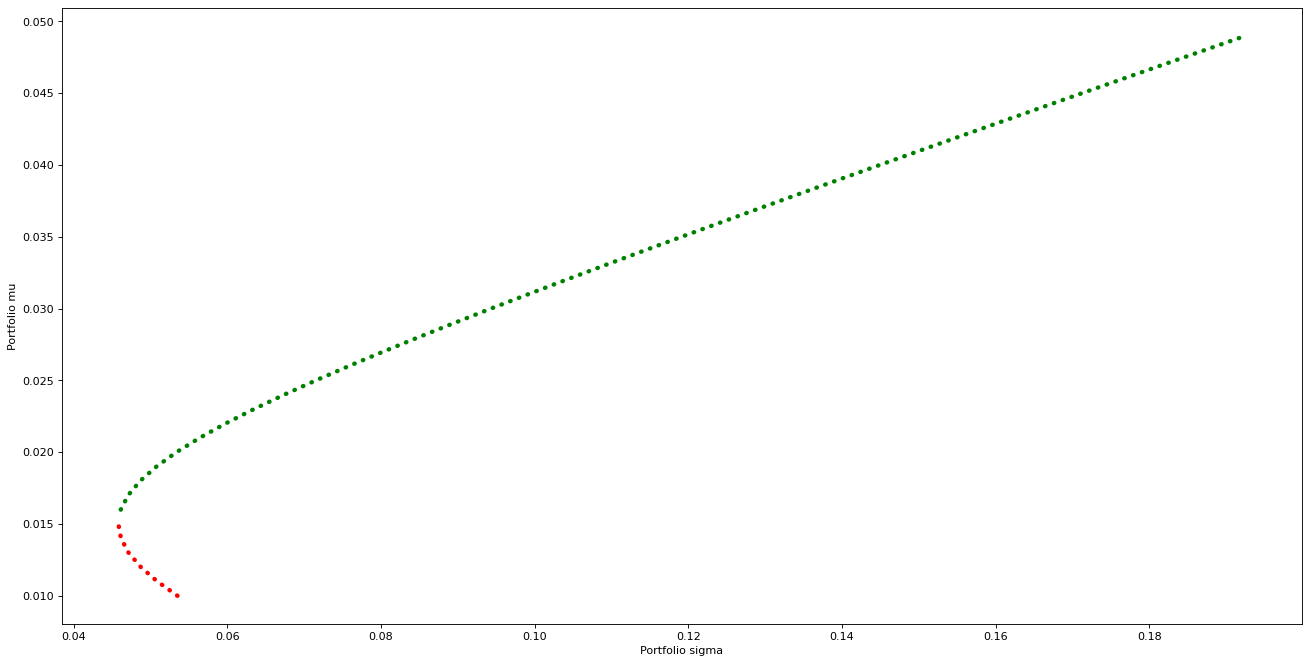

In [ ]:
plt.figure(figsize=(20, 10), dpi=80)
plt.plot(theoryData_posC['sigma_P'], theoryData_posC['C'], color='g', dash_capstyle = 'round',linestyle = (0,(0.1,2)),linewidth = 4)
plt.plot(theoryData_negC['sigma_P'], theoryData_negC['C'], color='r', dash_capstyle = 'round',linestyle = (0,(0.1,2)),linewidth = 4)
plt.xlabel('Portfolio sigma')
plt.ylabel('Portfolio mu')
plt.savefig("6stocks_theoretical_frontier.pdf")

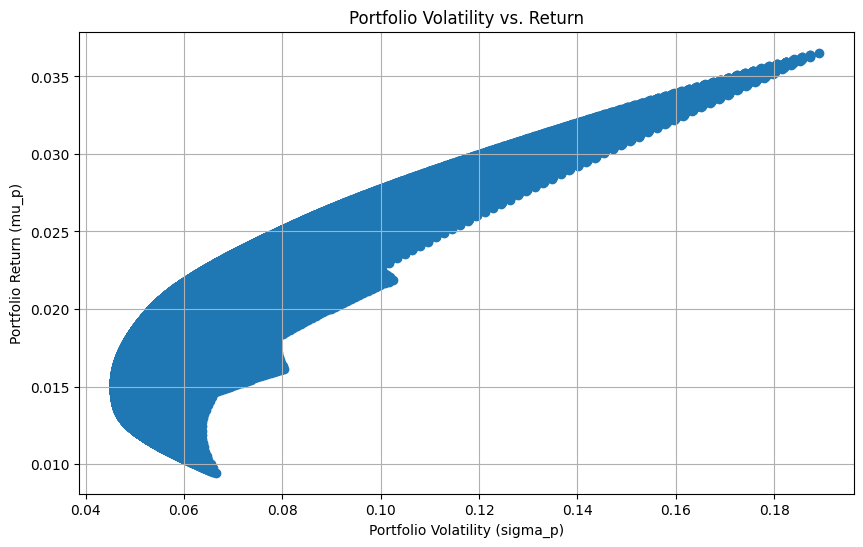

In [ ]:
# prompt: plot the scatter graph of resData mu_p on sigma_p

plt.figure(figsize=(10, 6))
plt.scatter(df_portfolios['sigma_p'], df_portfolios['mu_p'])
plt.xlabel('Portfolio Volatility (sigma_p)')
plt.ylabel('Portfolio Return (mu_p)')
plt.title('Portfolio Volatility vs. Return')
plt.grid(True)
plt.show()


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


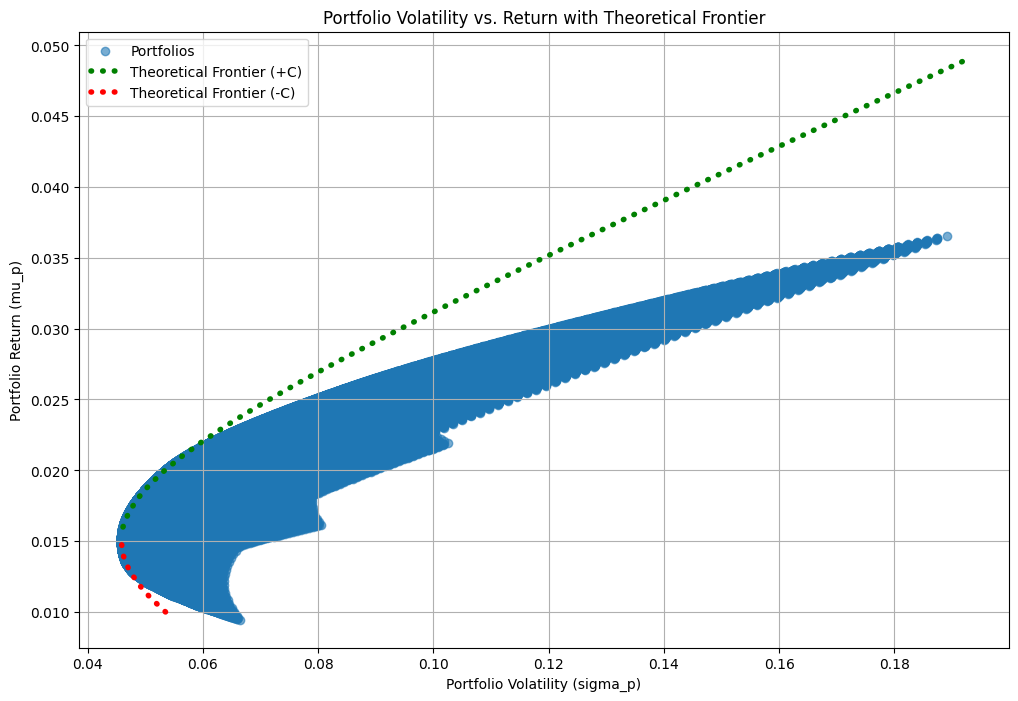

In [ ]:
import matplotlib.pyplot as plt

# Create one figure to hold all plots
plt.figure(figsize=(12, 8), dpi=100)

# Scatter plot of the portfolios
plt.scatter(df_portfolios['sigma_p'], df_portfolios['mu_p'], label='Portfolios', alpha=1)

# Plot the theoretical frontiers
plt.plot(theoryData_posC['sigma_P'], theoryData_posC['C'], color='g',
         dash_capstyle='round', linestyle=(0, (0.1, 2)), linewidth=4, label='Theoretical Frontier (+C)')
plt.plot(theoryData_negC['sigma_P'], theoryData_negC['C'], color='r',
         dash_capstyle='round', linestyle=(0, (0.1, 2)), linewidth=4, label='Theoretical Frontier (-C)')

# Labels and title
plt.xlabel('Portfolio Volatility (sigma_p)')
plt.ylabel('Portfolio Return (mu_p)')
plt.title('Portfolio Volatility vs. Return with Theoretical Frontier')
plt.grid(True)
plt.legend()

# Save and show
plt.show()

### Active frontier

In [ ]:
mu_2 = np.array([0.01,0.015,0.02,0.03,0.04,0.02])
mu_2 # belief that the mu and correlation matrix are different , so here we use mean returns that investor believes those stocks have

array([0.01 , 0.015, 0.02 , 0.03 , 0.04 , 0.02 ])

In [ ]:
A_2 = np.dot(np.dot(onesVec,np.linalg.inv(Omega)),mu_2)[0]
A_2

np.float64(10.299866881950724)

In [ ]:
B_2 = np.dot(np.dot(mu_2.transpose(),np.linalg.inv(Omega)),mu_2)
B_2

np.float64(0.3228386649465169)

In [ ]:
F_2 = float(np.dot(np.dot(onesVec,np.linalg.inv(Omega)),onesVec.transpose()))
F_2

<ipython-input-59-7b6659612b67>:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  F_2 = float(np.dot(np.dot(onesVec,np.linalg.inv(Omega)),onesVec.transpose()))


476.6366718705518

In [ ]:
D_2 = B_2*F_2-A_2**2
D_2

np.float64(47.789489025334674)

In [ ]:
alpha_0_2 = (np.dot((B_2*np.linalg.inv(Omega)),onesVec.transpose()).reshape(6) - np.dot((A_2*np.linalg.inv(Omega)),mu_2.transpose()))/D_2
alpha_0_2

array([ 1.05776398,  0.19153974,  0.16484957, -0.59028974, -0.12808821,
        0.30422465])

In [ ]:
alpha_1_2 = (np.dot((F_2*np.linalg.inv(Omega)),mu_2) - np.dot((A_2*np.linalg.inv(Omega)),onesVec.transpose().reshape(6)))/D_2
alpha_1_2

array([-35.41193672,  -6.72758973,  -1.27513417,  47.62095035,
         6.80165903, -11.00794876])

In [ ]:
stdVec_2 = np.empty((len(rbarVec),1))
stdVec_2[:] = np.nan

In [ ]:
for i in range(len(rbarVec)):
    rbar = rbarVec[i]
    w = alpha_0_2 + alpha_1_2*rbar
    stdVec_2[i] = (np.dot(np.dot(w.transpose(),Omega),w))**0.5

In [ ]:
theoryDataActive_dict = {"C":list(rbarVec), "sigma_P":list(stdVec_2.reshape(40,))}
theoryDataActive = pd.DataFrame(theoryDataActive_dict)
theoryDataActive.head()

,C,sigma_P
0,0.010,0.058671
1,0.011,0.056751
2,0.012,0.054946
3,0.013,0.053266
4,0.014,0.051726


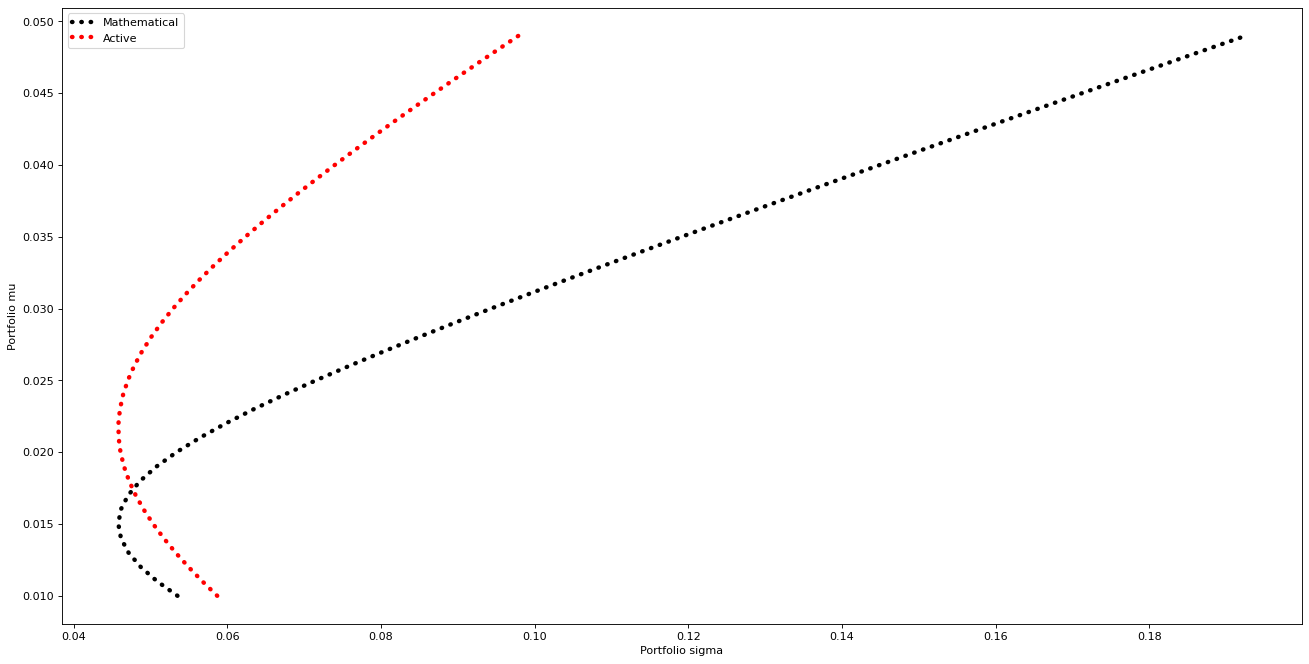

In [ ]:
plt.figure(figsize=(20, 10), dpi=80)
plt.plot(theoryData['sigma_P'], theoryData['C'], color='black', dash_capstyle = 'round',linestyle = (0,(0.1,2)),linewidth = 4,label = "Mathematical")
plt.plot(theoryDataActive['sigma_P'], theoryDataActive['C'], color='r', dash_capstyle = 'round',linestyle = (0,(0.1,2)),linewidth = 4, label = "Active")
plt.legend()
plt.xlabel('Portfolio sigma')
plt.ylabel('Portfolio mu')
plt.savefig("3stocks_active_frontier.pdf")

### Active investors and correlation

In [ ]:
Omega_2 = Omega
Omega_2

,O,LNG,MS,COST,BYDE,ASML
O,0.004413,0.001531,0.000760,0.001248,0.000633,0.001089
LNG,0.001531,0.010510,0.003410,0.001179,0.003726,0.001648
MS,0.000760,0.003410,0.006467,0.001200,0.003554,0.003566
COST,0.001248,0.001179,0.001200,0.003166,0.000732,0.001670
BYDE,0.000633,0.003726,0.003554,0.000732,0.035741,0.003865
ASML,0.001089,0.001648,0.003566,0.001670,0.003865,0.006148


In [ ]:
Omega_2.iloc[1,2] = 0.9*(Omega_2.iloc[1,1]*Omega_2.iloc[2,2])**0.5

Omega_2.iloc[2,1] = Omega_2.iloc[1,2]

Omega_2

,O,LNG,MS,COST,BYDE,ASML
O,0.004413,0.001531,0.000760,0.001248,0.000633,0.001089
LNG,0.001531,0.010510,0.007420,0.001179,0.003726,0.001648
MS,0.000760,0.007420,0.006467,0.001200,0.003554,0.003566
COST,0.001248,0.001179,0.001200,0.003166,0.000732,0.001670
BYDE,0.000633,0.003726,0.003554,0.000732,0.035741,0.003865
ASML,0.001089,0.001648,0.003566,0.001670,0.003865,0.006148


In [ ]:
A_2 = np.dot(np.dot(onesVec,np.linalg.inv(Omega_2)),mu)[0]
A_2

np.float64(3.407466280970329)

In [ ]:
B_2 = np.dot(np.dot(mu.transpose(),np.linalg.inv(Omega_2)),mu)
B_2

np.float64(0.34026417608436665)

In [ ]:
F_2 = float(np.dot(np.dot(onesVec,np.linalg.inv(Omega_2)),onesVec.transpose()))
F_2

<ipython-input-73-f7f12e7d3cab>:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  F_2 = float(np.dot(np.dot(onesVec,np.linalg.inv(Omega_2)),onesVec.transpose()))


531.852711256407

In [ ]:
D_2 = B_2*F_2-A_2**2
D_2

np.float64(169.35959813794813)

In [ ]:
alpha_0_2 = (np.dot((B_2*np.linalg.inv(Omega_2)),onesVec.transpose()).reshape(6) - np.dot((A_2*np.linalg.inv(Omega_2)),mu.transpose()))/D_2
alpha_0_2

array([ 0.62776579, -1.48236654,  2.29615964,  0.45152291,  0.04271859,
       -0.93580039])

In [ ]:
alpha_1_2 = (np.dot((F_2*np.linalg.inv(Omega_2)),mu) - np.dot((A_2*np.linalg.inv(Omega_2)),onesVec.transpose().reshape(6)))/D_2
alpha_1_2

array([ -23.69778035,   95.91269513, -139.13244585,    0.82673289,
         -0.29513797,   66.38593615])

In [ ]:
stdVec_2 = np.empty((len(rbarVec),1))
stdVec_2[:] = np.nan

In [ ]:
for i in range(len(rbarVec)):
    rbar = rbarVec[i]
    w = alpha_0_2 + alpha_1_2*rbar
    stdVec_2[i] = (np.dot(np.dot(w.transpose(),Omega_2),w))**0.5

In [ ]:
theoryDataActiveAgain_dict = {"C":list(rbarVec), "sigma_P":list(stdVec_2.reshape(40,))}
theoryDataActiveAgain = pd.DataFrame(theoryDataActiveAgain_dict)
theoryDataActiveAgain.head()

,C,sigma_P
0,0.010,0.043827
1,0.011,0.044119
2,0.012,0.044480
3,0.013,0.044908
4,0.014,0.045401


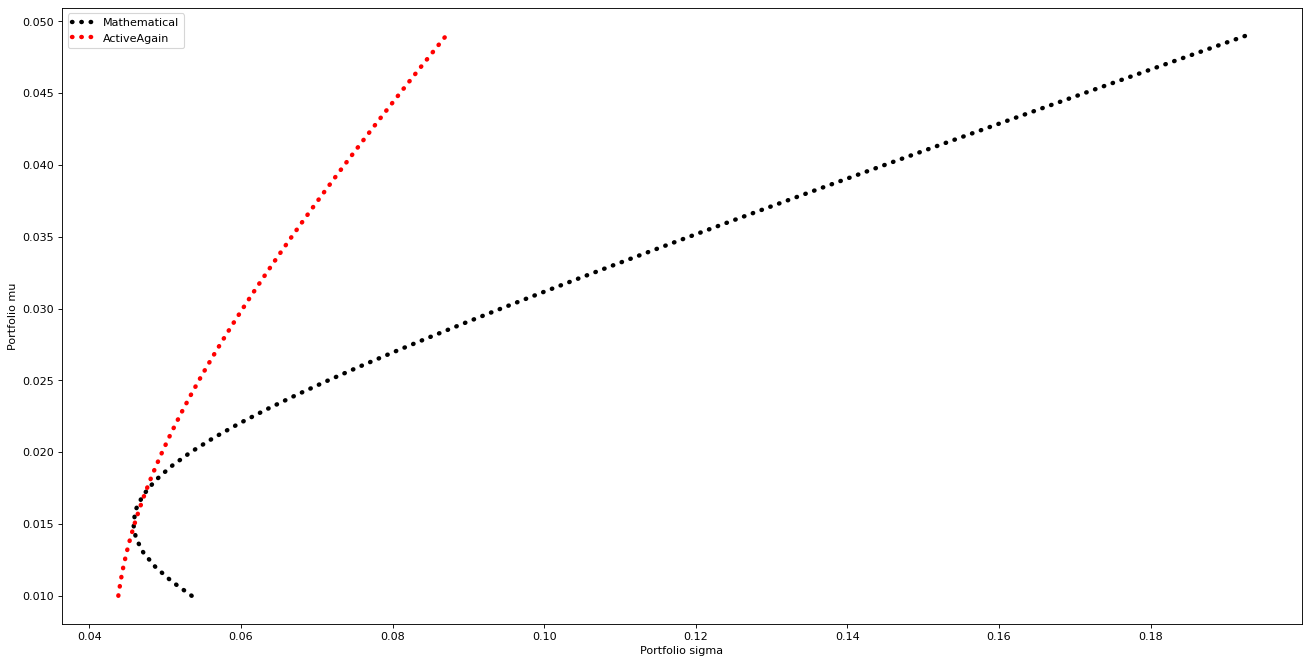

In [ ]:
plt.figure(figsize=(20, 10), dpi=80)
plt.plot(theoryData['sigma_P'], theoryData['C'], color='black', dash_capstyle = 'round',linestyle = (0,(0.1,2)),linewidth = 4,label = "Mathematical")
plt.plot(theoryDataActiveAgain['sigma_P'], theoryDataActiveAgain['C'], color='r', dash_capstyle = 'round',linestyle = (0,(0.1,2)),linewidth = 4, label = "ActiveAgain")
plt.legend()
plt.xlabel('Portfolio sigma')
plt.ylabel('Portfolio mu')
plt.savefig("3stocks_active_again_frontier.pdf")

### Start From here

### Include a risk-free asset and find the CML

In [ ]:
rf = 0.001

In [ ]:
maxSharpe = max((theoryData['C']-rf)/theoryData['sigma_P'])
maxSharpe
print(theoryData)

        C   sigma_P
0   0.010  0.053497
1   0.011  0.050872
2   0.012  0.048730
3   0.013  0.047137
4   0.014  0.046148
5   0.015  0.045804
6   0.016  0.046119
7   0.017  0.047080
8   0.018  0.048648
9   0.019  0.050768
10  0.020  0.053372
11  0.021  0.056396
12  0.022  0.059774
13  0.023  0.063450
14  0.024  0.067376
15  0.025  0.071510
16  0.026  0.075818
17  0.027  0.080272
18  0.028  0.084850
19  0.029  0.089532
20  0.030  0.094303
21  0.031  0.099150
22  0.032  0.104062
23  0.033  0.109031
24  0.034  0.114048
25  0.035  0.119109
26  0.036  0.124207
27  0.037  0.129339
28  0.038  0.134500
29  0.039  0.139687
30  0.040  0.144898
31  0.041  0.150129
32  0.042  0.155379
33  0.043  0.160646
34  0.044  0.165929
35  0.045  0.171225
36  0.046  0.176534
37  0.047  0.181855
38  0.048  0.187186
39  0.049  0.192527


In [ ]:
tangencyIdx = ((theoryData['C']-rf)/theoryData['sigma_P']).idxmax()
tangencyIdx

10

In [ ]:
theoryData.loc[tangencyIdx,:]

,10
C,0.020000
sigma_P,0.053372


In [ ]:
graphData = theoryData
graphData.rename(columns={"C": "Frontier"},inplace=True)
graphData.head()

,Frontier,sigma_P
0,0.010,0.053497
1,0.011,0.050872
2,0.012,0.048730
3,0.013,0.047137
4,0.014,0.046148


In [ ]:
graphData['variable'] = "Frontier"
graphData.rename(columns={"Frontier": "value"},inplace=True)
graphData.head()

,value,sigma_P,variable
0,0.010,0.053497,Frontier
1,0.011,0.050872,Frontier
2,0.012,0.048730,Frontier
3,0.013,0.047137,Frontier
4,0.014,0.046148,Frontier


In [ ]:
tmp = np.arange(0,6.1,0.1)
tmp

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
       1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5,
       2.6, 2.7, 2.8, 2.9, 3. , 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8,
       3.9, 4. , 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5. , 5.1,
       5.2, 5.3, 5.4, 5.5, 5.6, 5.7, 5.8, 5.9, 6. ])

In [ ]:
tmp2 = rf+tmp*maxSharpe
tmp2

array([1.00000000e-03, 3.65989110e-02, 7.21978221e-02, 1.07796733e-01,
       1.43395644e-01, 1.78994555e-01, 2.14593466e-01, 2.50192377e-01,
       2.85791288e-01, 3.21390199e-01, 3.56989110e-01, 3.92588021e-01,
       4.28186932e-01, 4.63785843e-01, 4.99384754e-01, 5.34983665e-01,
       5.70582577e-01, 6.06181488e-01, 6.41780399e-01, 6.77379310e-01,
       7.12978221e-01, 7.48577132e-01, 7.84176043e-01, 8.19774954e-01,
       8.55373865e-01, 8.90972776e-01, 9.26571687e-01, 9.62170598e-01,
       9.97769509e-01, 1.03336842e+00, 1.06896733e+00, 1.10456624e+00,
       1.14016515e+00, 1.17576406e+00, 1.21136298e+00, 1.24696189e+00,
       1.28256080e+00, 1.31815971e+00, 1.35375862e+00, 1.38935753e+00,
       1.42495644e+00, 1.46055535e+00, 1.49615426e+00, 1.53175317e+00,
       1.56735209e+00, 1.60295100e+00, 1.63854991e+00, 1.67414882e+00,
       1.70974773e+00, 1.74534664e+00, 1.78094555e+00, 1.81654446e+00,
       1.85214337e+00, 1.88774228e+00, 1.92334120e+00, 1.95894011e+00,
      

In [ ]:
tmpframe_dict = {"sigma_P":tmp,"value":tmp2}
tmpframe = pd.DataFrame(tmpframe_dict)
tmpframe['variable'] = 'CML'
tmpframe.head()

,sigma_P,value,variable
0,0.0,0.001000,CML
1,0.1,0.036599,CML
2,0.2,0.072198,CML
3,0.3,0.107797,CML
4,0.4,0.143396,CML


In [ ]:
# graphData = tmpframe.append(graphData)
graphData = pd.concat([tmpframe, graphData])
graphData.shape

(101, 3)

In [ ]:
graphData_f = graphData[graphData['variable']=='Frontier']
graphData_c = graphData[graphData['variable']=='CML']

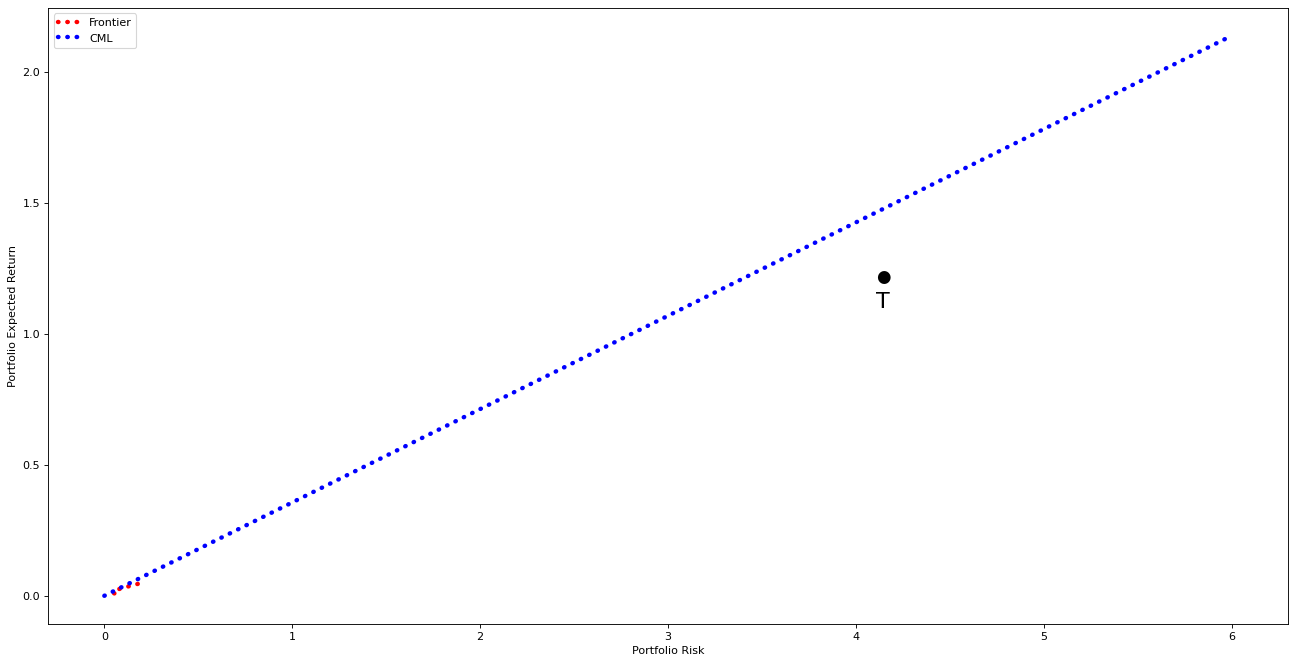

In [ ]:
plt.figure(figsize=(20, 10), dpi=80)
plt.plot(graphData_f['sigma_P'], graphData_f['value'], color='red', dash_capstyle = 'round',linestyle = (0,(0.1,2)),linewidth = 4,label = "Frontier")
plt.plot(graphData_c['sigma_P'], graphData_c['value'], color='blue', dash_capstyle = 'round',linestyle = (0,(0.1,2)),linewidth = 4, label = "CML")
plt.legend()

# Annotation UU.
plt.annotate("T",
            xy=(4.106,1.1), # arrow position (x, y)
            xytext=(4.106,1.1), # text position (x, y)
            color='black',
            fontsize=20)

plt.annotate("●",
            xy=(4.106,1.1), # arrow position (x, y)
            xytext=(4.106,1.2), # text position (x, y)
            color='black',
            fontsize=15)

plt.xlabel('Portfolio Risk')
plt.ylabel('Portfolio Expected Return')
plt.savefig("3stocks_tangency.pdf")

### Min var portfolio

In [ ]:
Omega = df_stocks[["UU.","GSK", "RIO"]].cov()
scalingFactor = float(np.dot(np.dot(onesVec,np.linalg.inv(Omega)),onesVec.transpose()))**-1
scalingFactor

KeyError: "None of [Index(['UU.', 'GSK', 'RIO'], dtype='object')] are in the [columns]"

In [ ]:
w_M = scalingFactor * np.dot(np.linalg.inv(Omega),onesVec.transpose())
w_M

In [ ]:
mu_M = np.dot(w_M.transpose(),mu)
mu_M

In [ ]:
sigma_M = float(np.dot(np.dot(w_M.transpose(),Omega),w_M))**(1/2)
sigma_M

### Multiple regression

# Perform the following performance measurement tasks.
a. Consider the portfolio from (6) that maximises the Sharpe ratio. Compute the returns on this portfolio in each month of the sample. Plot them and describe the statistical features of the return series.

b. A data spreadsheet (i.e., FR2209_assessment_data_factors.xlsx) has
been uploaded to Moodle that contains monthly percentage point returns for
a set of five international risk factors for developed markets for our sample period. These are the excess return on the market (XSMKT), a size factor (SMB), a value factor (HML), profitability (RMW) and an investment factor (CMA). Plot the returns on the factors and describe any interesting features.

c. Run a multivariate regression of your portfolio returns (from part (a)) on the factor returns (from part (b)). Present the results, interpret them statistically and then describe the implications of the regression for the risks that an investor in this portfolio faces.

In [ ]:
# prompt: select the first row from the df_portfolios_sorted_M and put it inside a table all these values

S_port = df_portfolios_sorted_S.iloc[0]
print(S_port)
print("An investor who wants to maximise Sharpe ratio. Portfolio S:")
print(S_port["w1_O"], S_port["w2_LNG"], S_port["w3_MS"], S_port["w4_Cost"], S_port["w5_BYDE"], S_port["w6_ASML"])

w1_O            0.020000
w2_LNG          0.170000
w3_MS           0.000000
w4_Cost         0.480000
w5_BYDE         0.090000
w6_ASML         0.240000
mu_p            0.019765
sigma_p         0.052740
Sharpe Ratio    0.355803
Name: 11247008, dtype: float64
An investor who wants to maximise Sharpe ratio. Portfolio S:
0.02 0.17 0.0 0.48 0.09 0.24


In [ ]:
print(df_stocks)

          date      ASML      BYDE      COST       LNG        MS         O
1   2013-02-28 -0.051560  0.080677 -0.007584  0.003297 -0.011031  0.049267
2   2013-03-29 -0.055735 -0.150530  0.047586  0.314555 -0.025277 -0.002571
3   2013-04-30  0.115695  0.727648  0.021864  0.017143  0.010089  0.127970
4   2013-05-31  0.123819  0.194257  0.013854  0.030548  0.169300 -0.104835
5   2013-06-28 -0.055869 -0.156176  0.008565 -0.054174 -0.056757 -0.073707
..         ...       ...       ...       ...       ...       ...       ...
115 2022-08-31 -0.139109  0.037324 -0.035470  0.073257  0.010913 -0.073828
116 2022-09-30 -0.128256 -0.092908 -0.095442  0.035772 -0.072870 -0.143995
117 2022-10-31  0.111827  0.202633  0.063817  0.063288  0.049798  0.074192
118 2022-11-30  0.239571  0.119648  0.075274 -0.003649  0.132652  0.016830
119 2022-12-30 -0.076473 -0.011784 -0.153454 -0.144845 -0.086494  0.009648

[119 rows x 7 columns]


In [ ]:
print(df_stocks["date"])

1     2013-02-28
2     2013-03-29
3     2013-04-30
4     2013-05-31
5     2013-06-28
         ...    
115   2022-08-31
116   2022-09-30
117   2022-10-31
118   2022-11-30
119   2022-12-30
Name: date, Length: 119, dtype: datetime64[ns]


In [ ]:
#["O", "LNG", "MS", "COST", "BYD", "ASML"]
w = np.array([S_port["w1_O"],S_port["w2_LNG"],S_port["w3_MS"],S_port["w4_Cost"],S_port["w5_BYDE"],S_port["w6_ASML"]])
print(w)
# mu_p = np.dot(w.transpose(),mu)
# mu_p


[0.02 0.17 0.   0.48 0.09 0.24]


In [ ]:
O = S_port["w1_O"] * df_stocks["O"]
LNG = S_port["w2_LNG"] * df_stocks["LNG"]
MS = S_port["w3_MS"] * df_stocks["MS"]
COST = S_port["w4_Cost"] * df_stocks["COST"]
BYDE = S_port["w5_BYDE"] * df_stocks["BYDE"]
ASML = S_port["w6_ASML"] * df_stocks["ASML"]
sum = O+LNG+MS+COST+BYDE+ASML
print(sum)


1     -0.007208
2      0.049340
3      0.109224
4      0.056946
5     -0.034037
         ...   
115   -0.036076
116   -0.081754
117    0.087951
118    0.104113
119   -0.117503
Length: 119, dtype: float64


In [ ]:
# prompt: Compute the returns on this portfolio with weights w for each month

# Assuming df_stocks contains monthly returns for the assets
portfolio_returns = df_stocks[["O", "LNG", "MS", "COST", "BYDE", "ASML"]].dot(w)
print(portfolio_returns)
# Rename the column to 'Portfolio Returns'
portfolio_returns = portfolio_returns.rename('Portfolio Returns')

# Concatenate the DataFrames
portfolio_returns = pd.concat([df_stocks["date"], portfolio_returns], axis=1)
print(portfolio_returns)


1     -0.007208
2      0.049340
3      0.109224
4      0.056946
5     -0.034037
         ...   
115   -0.036076
116   -0.081754
117    0.087951
118    0.104113
119   -0.117503
Length: 119, dtype: float64
          date  Portfolio Returns
1   2013-02-28          -0.007208
2   2013-03-29           0.049340
3   2013-04-30           0.109224
4   2013-05-31           0.056946
5   2013-06-28          -0.034037
..         ...                ...
115 2022-08-31          -0.036076
116 2022-09-30          -0.081754
117 2022-10-31           0.087951
118 2022-11-30           0.104113
119 2022-12-30          -0.117503

[119 rows x 2 columns]


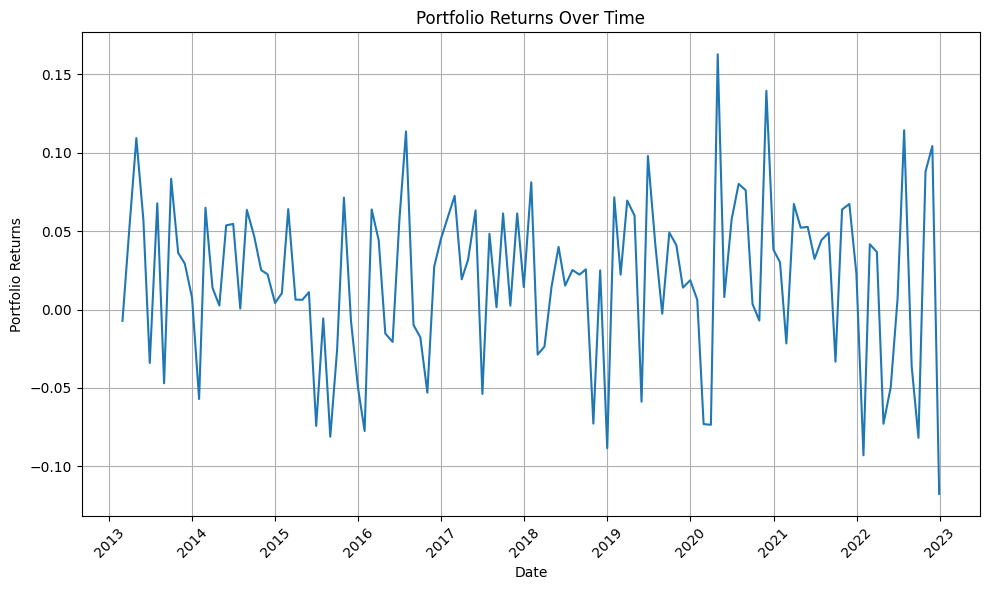

count    119.000000
mean       0.019765
std        0.052740
min       -0.117503
25%       -0.007244
50%        0.024924
75%        0.057270
max        0.162601
Name: Portfolio Returns, dtype: float64


In [ ]:
# prompt: # plot the graph

# Assuming portfolio_returns is already defined as in the previous code

plt.figure(figsize=(10, 6))
plt.plot(portfolio_returns['date'], portfolio_returns['Portfolio Returns'])
plt.xlabel('Date')
plt.ylabel('Portfolio Returns')
plt.title('Portfolio Returns Over Time')
plt.grid(True)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()


# Statistical features of the return series
print(portfolio_returns['Portfolio Returns'].describe())


In [ ]:
# prompt: read the data from google drive: FR2209_assessment_data_factors.xlsx

df_factors = pd.read_excel('/content/drive/MyDrive/FR2209_assessment_data_factors.xlsx')

df_factors.head()

,Date,XSMKT,SMB,HML,RMW,CMA
0,2013-02-28,0.09,0.36,-0.73,0.80,0.32
1,2013-03-29,2.30,0.64,-1.86,1.04,0.84
2,2013-04-30,3.02,-1.04,0.90,-0.21,1.19
3,2013-05-31,0.56,-0.58,0.90,-0.60,-1.04
4,2013-06-28,-2.52,0.29,-0.02,0.36,0.55


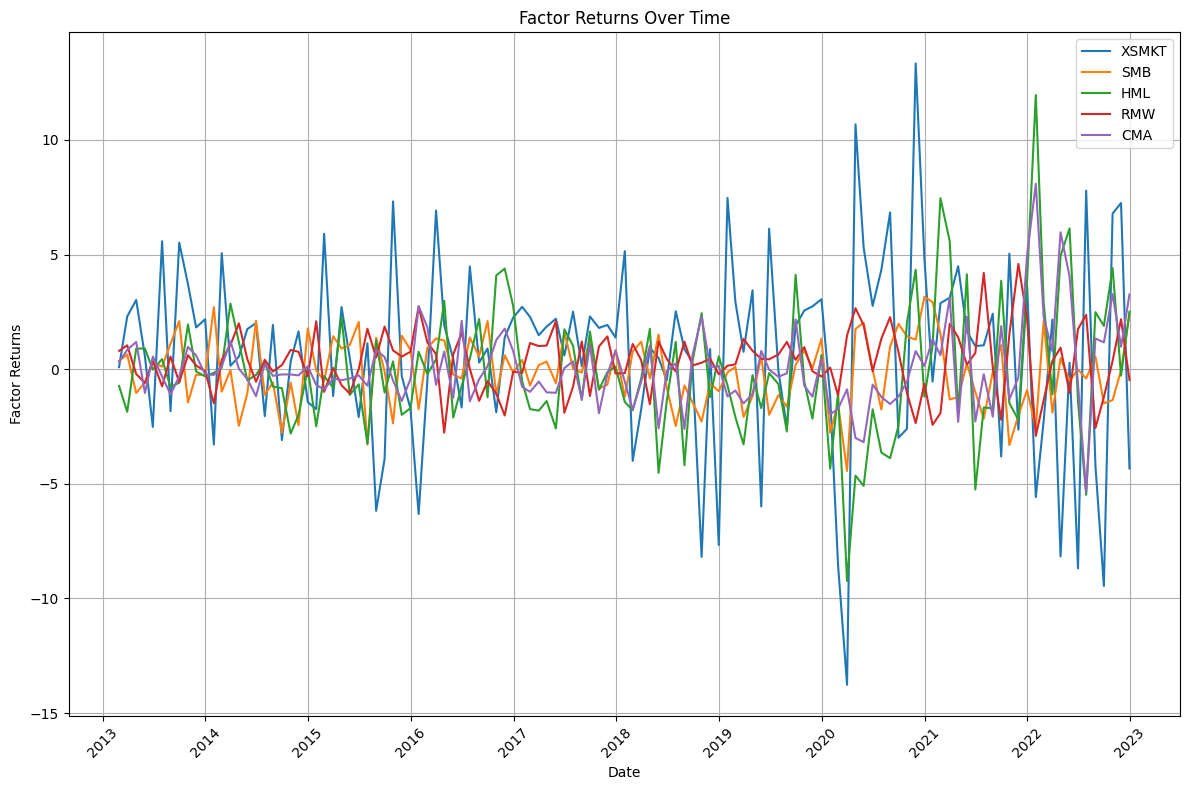


Statistical features for XSMKT:
count    119.000000
mean       0.706975
std        4.204784
min      -13.770000
25%       -1.735000
50%        1.040000
75%        2.750000
max       13.340000
Name: XSMKT, dtype: float64

Statistical features for SMB:
count    119.000000
mean      -0.123950
std        1.480848
min       -4.440000
25%       -1.105000
50%       -0.100000
75%        1.015000
max        3.160000
Name: SMB, dtype: float64

Statistical features for HML:
count    119.000000
mean      -0.110588
std        2.820208
min       -9.240000
25%       -1.705000
50%       -0.490000
75%        1.185000
max       11.960000
Name: HML, dtype: float64

Statistical features for RMW:
count    119.000000
mean       0.315546
std        1.317181
min       -2.910000
25%       -0.395000
50%        0.410000
75%        1.080000
max        4.590000
Name: RMW, dtype: float64

Statistical features for CMA:
count    119.000000
mean       0.051345
std        1.753325
min       -5.360000
25%       -0.9600

In [ ]:
# prompt: Plot the returns on the factors and describe any interesting features

# Assuming df_factors is already loaded as in the previous code

# Plotting the returns on the factors
plt.figure(figsize=(12, 8))

for column in df_factors.columns[1:]:  # Iterate through factor columns (excluding 'date')
    plt.plot(df_factors['Date'], df_factors[column], label=column)

plt.xlabel('Date')
plt.ylabel('Factor Returns')
plt.title('Factor Returns Over Time')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Describe statistical features of each factor return
for column in df_factors.columns[1:]:
    print(f"\nStatistical features for {column}:")
    print(df_factors[column].describe())


### **Multivariate Regression**

In [ ]:
print(df_factors)

          Date  XSMKT   SMB   HML   RMW   CMA
0   2013-02-28   0.09  0.36 -0.73  0.80  0.32
1   2013-03-29   2.30  0.64 -1.86  1.04  0.84
2   2013-04-30   3.02 -1.04  0.90 -0.21  1.19
3   2013-05-31   0.56 -0.58  0.90 -0.60 -1.04
4   2013-06-28  -2.52  0.29 -0.02  0.36  0.55
..         ...    ...   ...   ...   ...   ...
114 2022-08-31  -4.22  0.55  2.49 -2.57  1.34
115 2022-09-30  -9.46 -1.49  1.89 -1.21  1.17
116 2022-10-31   6.79 -1.35  4.41  0.36  3.28
117 2022-11-30   7.25 -0.05 -0.28  2.18  0.98
118 2022-12-30  -4.33  2.41  2.51 -0.47  3.26

[119 rows x 6 columns]


In [ ]:
print(portfolio_returns)

          date  Portfolio Returns
1   2013-02-28          -0.007208
2   2013-03-29           0.049340
3   2013-04-30           0.109224
4   2013-05-31           0.056946
5   2013-06-28          -0.034037
..         ...                ...
115 2022-08-31          -0.036076
116 2022-09-30          -0.081754
117 2022-10-31           0.087951
118 2022-11-30           0.104113
119 2022-12-30          -0.117503

[119 rows x 2 columns]


In [ ]:
# prompt: concat to dataframes base on the date and drop duplicated columns

# Merge the two dataframes based on the date column
merged_df = pd.merge(portfolio_returns, df_factors, left_on='date', right_on='Date', how='inner')

# Drop duplicated date column
merged_df = merged_df.drop(columns=['Date'])

# Now you can proceed with the multivariate regression on the merged DataFrame.
merged_df


,date,Portfolio Returns,XSMKT,SMB,HML,RMW,CMA
0,2013-02-28,-0.007208,0.09,0.36,-0.73,0.80,0.32
1,2013-03-29,0.049340,2.30,0.64,-1.86,1.04,0.84
2,2013-04-30,0.109224,3.02,-1.04,0.90,-0.21,1.19
3,2013-05-31,0.056946,0.56,-0.58,0.90,-0.60,-1.04
4,2013-06-28,-0.034037,-2.52,0.29,-0.02,0.36,0.55
...,...,...,...,...,...,...,...
114,2022-08-31,-0.036076,-4.22,0.55,2.49,-2.57,1.34
115,2022-09-30,-0.081754,-9.46,-1.49,1.89,-1.21,1.17
116,2022-10-31,0.087951,6.79,-1.35,4.41,0.36,3.28
117,2022-11-30,0.104113,7.25,-0.05,-0.28,2.18,0.98


In [ ]:
# prompt: run the multiple linear regression using stats model

import statsmodels.api as sm

# Define the independent variables (factors) and dependent variable (portfolio returns)
X = merged_df[['XSMKT', 'SMB', 'HML', "RMW", "CMA"]]  # Independent variables
y = merged_df['Portfolio Returns']  # Dependent variable

# Add a constant to the independent variables (intercept term)
X = sm.add_constant(X)

# Fit the OLS model
model = sm.OLS(y, X).fit()

# Print the regression results
print(model.summary())

# Access specific statistics from the results
print("\nCoefficients:", model.params)
print("\nR-squared:", model.rsquared)
print("\nP-values:", model.pvalues)




                            OLS Regression Results                            
Dep. Variable:      Portfolio Returns   R-squared:                       0.704
Model:                            OLS   Adj. R-squared:                  0.691
Method:                 Least Squares   F-statistic:                     53.68
Date:                Tue, 08 Apr 2025   Prob (F-statistic):           2.79e-28
Time:                        16:42:51   Log-Likelihood:                 254.17
No. Observations:                 119   AIC:                            -496.3
Df Residuals:                     113   BIC:                            -479.7
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0104      0.003      3.696      0.0

In [ ]:
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.compat import lzip

# Serial Correlation Test (Ljung-Box)
print("\nLjung-Box Test for Serial Correlation:")
print("\nLjung-Box Test:")
print(acorr_ljungbox(model.resid, lags=[10]))



Ljung-Box Test for Serial Correlation:

Ljung-Box Test:
     lb_stat  lb_pvalue
10  7.062753   0.719508


In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan, het_white

# Heteroskedasticity Test (Breusch-Pagan)
print("\nBreusch-Pagan Test for Heteroskedasticity:")
bp_test = het_breuschpagan(model.resid, model.model.exog)
labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
print(dict(zip(labels, bp_test)))

white_test = het_white(model.resid, model.model.exog)
print("\nWhite Test:")
print(white_test)


Breusch-Pagan Test for Heteroskedasticity:
{'Lagrange multiplier statistic': np.float64(10.111833281809492), 'p-value': np.float64(0.07212780922139804), 'f-value': np.float64(2.098735235026393), 'f p-value': np.float64(0.07066124237990105)}

White Test:
(np.float64(28.89874463573487), np.float64(0.08977232449371232), np.float64(1.5716079442247377), np.float64(0.07546169297975382))


In [ ]:
from statsmodels.stats.diagnostic import het_arch

# 'model' is your original OLS regression
arch_test = het_arch(model.resid)

print("ARCH Test for Heteroskedasticity:")
print(f"Test statistic: {arch_test[0]:.4f}")
print(f"P-value: {arch_test[1]:.4f}")


ARCH Test for Heteroskedasticity:
Test statistic: 11.3709
P-value: 0.3294


In [ ]:
from statsmodels.stats.diagnostic import acorr_breusch_godfrey

bg_test = acorr_breusch_godfrey(model, nlags=5)
print("Breusch-Godfrey Test:")
print(f"LM stat: {bg_test[0]:.4f}, p-value: {bg_test[1]:.4f}")


Breusch-Godfrey Test:
LM stat: 4.1729, p-value: 0.5248


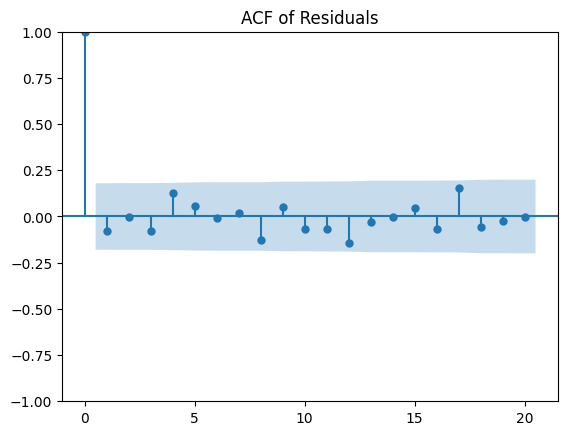

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(model.resid, lags=20)
plt.title("ACF of Residuals")
plt.show()


In [ ]:
# prompt: reestimate the model but now removing the variables that have a p value more then 10 %

# Assuming 'model' is the OLS regression model from the previous code

# Get p-values for each variable
p_values = model.pvalues

# Identify variables with p-values greater than 0.10
variables_to_remove = p_values[p_values > 0.15].index.tolist()

# Remove the constant term if present
if 'const' in variables_to_remove:
  variables_to_remove.remove('const')

# Re-estimate the model without the insignificant variables
if variables_to_remove:
  X_new = X.drop(columns=variables_to_remove)
  model_new = sm.OLS(y, X_new).fit()
  print(model_new.summary())

  # Perform diagnostic tests again with the new model
  print("\nLjung-Box Test for Serial Correlation:")
  print(acorr_ljungbox(model_new.resid, lags=[10]))

  print("\nBreusch-Pagan Test for Heteroskedasticity:")
  bp_test_new = het_breuschpagan(model_new.resid, model_new.model.exog)
  labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
  print(dict(zip(labels, bp_test_new)))

  white_test_new = het_white(model_new.resid, model_new.model.exog)
  print("\nWhite Test:")
  print(white_test_new)

  arch_test_new = het_arch(model_new.resid)
  print("\nARCH Test for Heteroskedasticity:")
  print(f"Test statistic: {arch_test_new[0]:.4f}")
  print(f"P-value: {arch_test_new[1]:.4f}")

  bg_test_new = acorr_breusch_godfrey(model_new, nlags=5)
  print("\nBreusch-Godfrey Test:")
  print(f"LM stat: {bg_test_new[0]:.4f}, p-value: {bg_test_new[1]:.4f}")

else:
  print("No variables removed. All variables have p-values <= 0.10.")


                            OLS Regression Results                            
Dep. Variable:      Portfolio Returns   R-squared:                       0.696
Model:                            OLS   Adj. R-squared:                  0.688
Method:                 Least Squares   F-statistic:                     87.69
Date:                Tue, 08 Apr 2025   Prob (F-statistic):           1.38e-29
Time:                        16:43:34   Log-Likelihood:                 252.60
No. Observations:                 119   AIC:                            -497.2
Df Residuals:                     115   BIC:                            -486.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0116      0.003      4.225      0.0

In [ ]:
# prompt: Present the results, interpret them statistically
# and then describe the implications of the regression for the risks that an
# investor in this portfolio faces.

# Assuming 'model' (or 'model_new' if variables were removed) is the final OLS regression model.

# Interpretation of Regression Results:

# 1. Coefficients:
#    - The coefficients represent the estimated impact of each factor on the portfolio's monthly returns.
#    - A positive coefficient suggests that an increase in the factor's return is associated with a higher portfolio return, and vice versa.
#    - The magnitude of the coefficient indicates the strength of this relationship.  For example, if the coefficient for 'XSMKT' (market excess return) is 0.8, it means that a 1% increase in the market excess return is associated with a 0.8% increase in the portfolio return.

# 2. Statistical Significance:
#    - P-values associated with each coefficient indicate the statistical significance of the relationship.
#    - Typically, p-values below 0.05 are considered statistically significant.  If a p-value is greater than 0.05, we fail to reject the null hypothesis that there is no relationship between the corresponding factor and the portfolio return.

# 3. R-squared:
#    - The R-squared measures the proportion of variance in the portfolio returns explained by the factors included in the model.
#    - Higher R-squared values (closer to 1) suggest a better fit.


# Implications for Investor Risks:

# 1. Factor Exposures:
#    - The coefficients indicate the portfolio's sensitivity to each factor.  A portfolio with a high coefficient for 'SMB' (size factor), for example, is more exposed to the risk associated with small company stocks.
#    - By understanding the coefficients, investors can assess the composition of their risk. If a factor has a large positive coefficient, then an adverse move in that factor can lead to a significant decrease in the portfolio return.

# 2. Hedging Strategies:
#    - Investors can use the regression results to develop hedging strategies.  If a factor carries substantial risk, investors can try to offset that risk by taking positions in other assets that are negatively correlated with that factor.  This may reduce the portfolio's overall risk profile.

# 3. Performance Attribution:
#    - The regression can explain variations in portfolio returns and attribute these variations to different risk factors.  Positive or negative surprises in those risk factors would result in positive or negative impacts on the portfolio's performance, given the factor exposures reflected by the regression coefficients.
#    - By comparing the actual portfolio returns to those predicted by the regression model, investors can identify unexpected events or changes in market conditions that significantly influence the portfolio's returns.

# 4. Risk Management:
#    - The regression analysis and resulting diagnostics help investors assess the quality of the model and identify any limitations.  If the model's diagnostics reveal issues such as heteroskedasticity or autocorrelation, investors may adjust the portfolio or model accordingly.
#    - Heteroskedasticity implies that the variance of the errors changes across observations.  Autocorrelation means there's a correlation between the errors in different time periods, suggesting the model may be missing some dynamic elements of the portfolio's returns.
#    - Addressing these issues helps to improve risk assessment and portfolio management.



# Example (replace with actual values from your model summary):

# Assume the coefficient for 'XSMKT' is 0.8 with a p-value of 0.02 and the R-squared is 0.70.

# Interpretation:
# - The portfolio's return is highly sensitive to market movements (0.8).
# - This sensitivity is statistically significant (p < 0.05).
# - The model explains 70% of the variation in the portfolio returns.

# Implications:
# - A significant portion of the portfolio's risk comes from market risk.
# - Investors might consider hedging against market downturns.
# - The portfolio is heavily exposed to the market (beta is a measure of systematic risk); a decline in the overall market would result in a relatively large decrease in the portfolio's value.


In [ ]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 985.3/985.3 kB 10.8 MB/s eta 0:00:00


In [ ]:
from arch import arch_model

# Let's say your returns series is:
returns = portfolio_returns['Portfolio Returns']

# Fit a GARCH(1,1) model with constant mean
garch_model = arch_model(returns, vol='GARCH', p=1, q=1, mean='Constant', dist='normal')
garch_result = garch_model.fit(disp='off')

print(garch_result.summary())


                     Constant Mean - GARCH Model Results                      
Dep. Variable:      Portfolio Returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                183.089
Distribution:                  Normal   AIC:                          -358.179
Method:            Maximum Likelihood   BIC:                          -347.062
                                        No. Observations:                  119
Date:                Sun, Apr 06 2025   Df Residuals:                      118
Time:                        18:51:24   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0205  4.615e-03      4.451  8.545e-06 [1.

/usr/local/lib/python3.11/dist-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.002758. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


In [ ]:
import statsmodels.api as sm

# Assuming 'portfolio_returns' and 'X_new' are your DataFrames

# Reset index of 'returns' to numerical index if it's not already
returns = portfolio_returns['Portfolio Returns'].reset_index(drop=True)

# Reset index of X_new to numerical index
X = X_new.reset_index(drop=True)

# Add constant to X_new
X_new = sm.add_constant(X)

# Now perform the regression
modelGarch = sm.OLS(returns, X_new).fit()
print(modelGarch.summary())

                            OLS Regression Results                            
Dep. Variable:      Portfolio Returns   R-squared:                       0.670
Model:                            OLS   Adj. R-squared:                  0.665
Method:                 Least Squares   F-statistic:                     118.0
Date:                Sun, 06 Apr 2025   Prob (F-statistic):           1.09e-28
Time:                        18:55:54   Log-Likelihood:                 247.84
No. Observations:                 119   AIC:                            -489.7
Df Residuals:                     116   BIC:                            -481.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0118      0.003      4.134      0.0

In [ ]:
# Example: include X variables in the mean equation
z = X.drop(columns=['const'])
print(z)
garch_model = arch_model(returns, vol='GARCH', p=1, q=1, mean='ARX', x=z, dist='normal')
garch_result = garch_model.fit(disp='off')
print(garch_result.summary())


     XSMKT   SMB
0     0.09  0.36
1     2.30  0.64
2     3.02 -1.04
3     0.56 -0.58
4    -2.52  0.29
..     ...   ...
114  -4.22  0.55
115  -9.46 -1.49
116   6.79 -1.35
117   7.25 -0.05
118  -4.33  2.41

[119 rows x 2 columns]
                          AR-X - GARCH Model Results                          
Dep. Variable:      Portfolio Returns   R-squared:                       0.670
Mean Model:                      AR-X   Adj. R-squared:                  0.664
Vol Model:                      GARCH   Log-Likelihood:                251.440
Distribution:                  Normal   AIC:                          -490.879
Method:            Maximum Likelihood   BIC:                          -474.205
                                        No. Observations:                  119
Date:                Sun, Apr 06 2025   Df Residuals:                      116
Time:                        18:56:35   Df Model:                            3
                                   Mean Model                

/usr/local/lib/python3.11/dist-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0009089. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
